In [36]:
%config InlineBackend.figure_format = 'retina'  

##### ============================
##### Load dependencies
##### ============================

import matplotlib.pyplot as plt; import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Patch; from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, zoomed_inset_axes, mark_inset
import matplotlib.dates as mdates; import matplotlib.ticker as mticker; import matplotlib.gridspec as gridspec

import xesmf as xe; import cmocean
import numpy as np; import pandas as pd; import xarray as xr
import cartopy.crs as ccrs; import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

plt.rcParams["font.family"] = "cmr10"
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["text.usetex"] = True
plt.rcParams["font.size"] = 12

import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

In [38]:
##### ============================
##### Load Data
##### ============================

with xr.open_dataset('files/hist_gcb_w14_ocean_static.nc') as ds:
        area   = ds.area_t.load() # yh:576 xh:720   
        area_wet = ds.wet.load()
        geolon = ds.geolon  
        geolat = ds.geolat
        depth = ds.depth_ocean

ds_out = xr.Dataset({ "lat": (["lat"], area.yh.values), "lon": (["lon"], area.xh.values)})
glob_ocn_mask = xr.open_dataset("files/global_ocean_mask.nc")['masks_r_glob']

##### ============================
##### Plotting Functions
##### ============================

def plot_subplot_iav_std(ax, data, title, vmin, vmax, cmap, levels, extend, level_label, label):
    ax.set_title(title, fontsize=14)
    ax.set_title(number, loc='left', fontsize=14, fontweight='semibold')

    im = ax.contourf(data.xh, data.yh, data.where(glob_ocn_mask), levels = np.linspace(vmin, vmax, levels),
                     transform=ccrs.PlateCarree(), cmap=cmap, extend=extend,)
#                      cbar_kwargs={'label':label})

    cbar = plt.colorbar(im, orientation='vertical', ticks=np.linspace(vmin, vmax, level_label), shrink=0.6, pad=0.1, ax=ax)
    cbar.set_label(label)
    
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgrey', linewidth=0.5)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    gl.top_labels = False
    gl.xlines = True
    gl.xlocator = mticker.FixedLocator([-120, 0, 120])
    gl.ylocator = mticker.FixedLocator([-60, -30, 0, 30, 60])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12, 'color': 'gray'}
    gl.ylabel_style = {'size': 12, 'color': 'gray'}    
    return im  # Return the contour plot for colorbar
    
colors=['darkblue','skyblue', 'white','orange','red']
cmap_diff = LinearSegmentedColormap.from_list('custom_kw', colors, N=21)

# Figure 1

a) Normalized gas transfer velocity ($k_{w,660}$) dependence on neutral wind speed (U$_{10\text{N}}$). 
Empirical fits (lines) based on eddy covariance (green filled circles), dual tracer (brown circles), and global radiocarbon ($^{14}$C, squares) methods. The red line is the Wanninkhof (2014) wind-dependent gas transfer velocity formulation. The blue shading is the count of daily gas transfer velocities using Deike and Melville’s (2018) wind-wave-bubble formulation (DM18) for the 1971-2020 period implemented in the MOM6-COBALTv2 model. The dashed blue line is the DM18 mean wind-wave-bubble gas transfer velocity at a given wind speed (noted $\langle\text{DM18}\rangle$). The gas transfer velocity is normalized to CO$_{2}$ transfer at 20\textdegree C, 35 psu (cm hr$^{-1}$), and U$_{10\text{N}}$ assumes atmospheric stability (m s$^{-1}$). 99.9\% values lie under 20 m s$^{-1}$ wind speed (\textcolor{blue}{white background} \sout{gray shading}). For data and fit references, see Fig. S1. b,c) Seasonal averages of significant wave height (colors in m) and 10 m wind speed (vectors in m s$^{-1}$) in boreal (DJF) and austral (JJA) winter.

In [3]:
##### ============================
##### Load Data
##### ============================

hist_dm18 = xr.open_dataset("files/summed_histogram_dm18.nc")['histogram_dic_kw_dic_u10']
bin_means = xr.open_dataset("files/kw_u10N_bin_means.nc")

##### ============================
##### Dual Tracer Data
##### ============================

#Hudson Bay Clark (1993,1994)
DT_Clark_1993_u_10 = [3.9,2.5,4.9,3.1,3.2,2.8,3.2]
DT_Clark_1993_k_w = [3.9,1.5,9,6.3,3.5,3.6,5.9]

DT_Clark_1994_u_10 = [2.9,3.1,2.7,1.3,2.4,5.1,4.2,3.4]
DT_Clark_1994_k_w = [6.7,6.1,4.2,2.8,5.6,9.1,6.7,6.5]

#Global C14 Constraint [Watson (1991)]

global_c14_u_10 = 7.92464432456606
global_c14_k_w = 21.56

#Global C14 Constraint [Naegler (2006)]
global_excess_c14_u_10 = 7.8857715430861735
global_excess_c14_k_w = 17.54204398447608

#Global C14 Constraint [Broecker (1986)]
global_Broecker_c14_u_10 = 7.4
global_Broecker_c14_k_w = 21.9
global_Broecker_c14_k_w_e = 3.3

#North Sea (1991)
DT_Watson_NAtl_u_10 =[12.1,17.5,11.7,11.9] 
DT_Watson_NAtl_k_w  =[21.7,54.2,17,17.8]

#DT, Georges Bank, Asher and Wanninkhof (1998)
DT_Asher_1998_u_10 = [3.4669338677354715, 5.170340681362726,8.096192384769541,10.601202404809621]
DT_Asher_1998_k_w = [0.3104786545925151,11.021992238033647,21.11254851228979,21.888745148771036]

#Kubis Fjords (2019)
DT_Kubis_fjords_2019_u_10=[3.0683622880667034, 3.1759726049038175,3.1979035503041278, 3.047620817671154, 
3.0073273518848236,1.0953206239168178, 0.4947100886995255, 0.47352256517719127, 
0.8387285627331948,0.8176525524925591,1.0535774854684323, 1.3109129685300296, 
1.3106155997788385, 1.0315350267864254, 1.0742074425822814,2.1478201476621823, 
2.1479316609438808, 2.5782242439167344,3.0292954683790345, 2.579413718921499, 
4.4871457710911375, 4.487777679687417, 3.999758387889683, 5.685764864952803, 
4.807746455968546, 4.808080995813635, 9.160630235897118, 7.85454950957393, 
9.678572258283408, 9.657979472263454, 7.082691744764729, 5.944921731615443, 
5.3653872066387915, 5.9460368644324095, 5.389659930954727, 6.4401522156295545, 
6.290204022841676, 6.376255105217469, 7.706720069138283, 7.083360824454909, 
6.573299073975162, 6.57378229819585, 0.43044126734844745] 

DT_Kubis_fjords_2019_k_w=[3.6395147313691467,4.679376083188913,6.031195840554595,5.615251299826689,
12.89428076256499,4.055459272097053,3.8474870017331,4.575389948006929,
6.239168110918534, 7.2790294627383005,7.2790294627383005,7.175043327556331,
6.343154246100518,5.615251299826689, 4.991334488734836,8.42287694974003,
8.73483535528596, 12.47833622183709,14.350086655112655,15.805892547660314,
12.686308492201029,14.454072790294624,29.22010398613517,5.823223570190635,
9.566724436741758,10.50259965337954,6.759098786828417,12.998266897746959,
15.70190641247833,18.09358752166377,13.726169844020788,10.814558058925464,
9.566724436741758,13.934142114384741,17.46967071057191,16.221837088388206,
16.74176776429809,17.46967071057191,19.44540727902946,15.597920277296353,
28.700173310225296,30.051993067590978,4.055459272097053]

#Kubis Open Water (2019)
DT_Kubis_open_2019_u_10 = [6.206346035005916, 6.057029750814321, 6.229280599941491, 6.057810343786196, 
7.5168872925969605, 8.181617964789732, 7.540267910659322, 6.921778079276693, 
6.322840243284849, 3.7082254984411573, 3.7301936149353683, 4.108632521919356, 
5.439543538966957, 5.24499003350048, 4.92293967596102, 4.943978515107757, 
5.244432467091999, 5.244246611622502]

DT_Kubis_open_2019_k_w= [22.149046793760824,24.43674176776429,26.308492201039854,26.620450606585784,
28.388214904679373,27.972270363951466,33.795493934142115,43.57019064124783,
48.041594454072786,53.656845753899475,55.11265164644714,33.795493934142115,
37.019064124783355,32.75563258232235,31.819757365684573,30.675909878682837,
31.19584055459272,30.675909878682837]

#DT  SOLAS Air-Sea Gas Exchange (SAGE) - Western Pacific, Southern Ocean - Ho (2006) 

DT_Ho_2006_u_10 = [8.897795591182367, 7.394789579158319, 8.99799599198397, 8.69739478957916, 
10.400801603206416, 10.781563126252507, 11.282565130260524, 11.48296593186373, 
15.490981963927862, 15.991983967935877]

DT_Ho_2006_k_w =[13.350582147477368,23.13065976714101,31.203104786545936,25.459249676584747,
29.029754204398458,36.946959896507124,30.116429495472204,28.40879689521347,
50.76326002587324,78.39586028460545]

# DT_Ho_2016

DT_Ho_2011_k_w = [17.48971193415639,24.176954732510296,26.748971193415628]
DT_Ho_2011_u_10 = [8.194250137037855, 8.870726259725597, 11.177093815706584] 

#Nightingale 2000a Southern North Sea
DT_Nightingale_2000_u_10 = [10,14.7,10.1,10.6,8.2,11.4,5.9,7.6,12.5]
DT_Nightingale_2000_k_w_600 = [24.8,61.9,18.9,19.8,14.4,41.7,7.17,21.6,26.5]

DT_Nightingale_2000_k_w = [i * 0.953 for i in DT_Nightingale_2000_k_w_600]

#wanninkhof (1997), West Florida Shelf

DT_Wanninkhof_1997_u_10 = 4.4
DT_Wanninkhof_1997_k_w = 8.4

#Wanninkhof SOFEX (2004)
DT_Wanninkhof_2004_u_10 = [9.8,11.3,7.8,9.3,8.8]
DT_Wanninkhof_2004_k_w = [27.7,66.1,23.9,44.1,31.6]

##### ============================
##### Eddy Covariance Data
##### ============================

# Updated data- Yang et al. (2022)

# Knorr07 - Jun/Jul 2007 - North Atlantic - Miller et al., (2009)
y22_Knorr07_u = [3.969, 6.021, 7.984,  9.991]
y22_Knorr07_kw = [9.679, 17.38, 25.37, 32.21]

y22_data_ec_Knorr07 = xr.DataArray(data = [y22_Knorr07_u, y22_Knorr07_kw], dims=['u10n','kw'], 
                               attrs=dict(description='Knorr07 - Miller - 2009 - Yang'))

# NBP-1210/ 1402 - Jan/Feb 2013, Feb/Mar 2014 - SO - Butterworth & Miller (2016)
y22_nbp1210_u = [1.961, 3.968, 5.974, 7.937, 9.988, 12.00, 14.01, 16.01]
y22_nbp1210_kw = [2.263, 7.676, 11.94, 21.36, 26.49, 34.48, 49.34, 54.18]

y22_data_ec_nbp1210 = xr.DataArray(data = [y22_nbp1210_u, y22_nbp1210_kw], dims=['u10n','kw'], 
                               attrs=dict(description='NBP-1210 - Butterworth & Miller - 2016 - Yang'))

# HiWinGS - Oct/Nov 2013 - North Atlantic - Blomquist et al., 2017
y22_hiwings_u = [1.964, 4.013, 5.974, 7.983, 9.992, 12.00, 14.02, 16.03, 18.03, 19.993, 22.07, 24.04]
y22_hiwings_kw = [7.128, 8.820, 13.38, 23.08, 33.65, 48.22, 67.65, 79.65, 88.78, 128.0, 144.8, 174.0]

y22_data_ec_hiwings = xr.DataArray(data = [y22_hiwings_u, y22_hiwings_kw], dims=['u10n','kw'], 
                               attrs=dict(description='HiWinGS - Blomquist - 2017 - Yang'))

# Knorr11 - Jun/Jul 2011 - North Atlantic - Bell et al., (2017)
y22_Knorr11_u = [3.925, 5.975, 7.983, 9.993, 12.00, 14.00, 16.01, 18.03, 20.08]
y22_Knorr11_kw = [10.54, 13.95, 24.23, 36.51, 41.06, 41.32, 47.02, 84.20, 91.90]

y22_data_ec_Knorr11 = xr.DataArray(data = [y22_Knorr11_u, y22_Knorr11_kw], dims=['u10n','kw'], 
                               attrs=dict(description='Knorr11 - Bell - 2017 - Yang'))

# SO-234/235 - Jul/Aug 2014 - Tropical Indian - Zavarsky et al., (2018)
y22_SO234_u = [3.967, 5.929, 8.024, 9.986, 12.00, 14.00, 15.97 ]
y22_SO234_kw = [6.818, 12.23, 17.07, 21.91, 33.05, 29.59, 48.74] 

y22_data_ec_SO234 = xr.DataArray(data = [y22_SO234_u, y22_SO234_kw], dims=['u10n','kw'], 
                               attrs=dict(description='SO-234/235 - Zavarsky - 2018 - Yang'))

# SOAP - Feb/Mar 2012 - SO - Landwehr et al., (2018)
y22_SOAP_u = [5.838, 7.177, 9.094, 10.44, 11.73, 13.74, 15.88]
y22_SOAP_kw = [8.512, 13.93, 18.20, 30.21, 37.92, 49.91, 61.91] 

y22_data_ec_SOAP = xr.DataArray(data = [y22_SOAP_u, y22_SOAP_kw], dims=['u10n','kw'], 
                               attrs=dict(description='SOAP - Landwehr - 2018 - Yang'))


# ANDREXII - Feb/Apr 2019 - SO - Yang et al,. 2021
y22_ANDREXII_u = [3.979, 6.019, 7.982, 9.990, 12.00, 14.02, 16.02, 18.03]
y22_ANDREXII_kw = [7.390, 14.52, 20.79, 30.78, 42.49, 47.05, 78.07, 59.16] 

y22_data_ec_ANDREXII = xr.DataArray(data = [y22_ANDREXII_u, y22_ANDREXII_kw], dims=['u10n','kw'], 
                               attrs=dict(description='ANDREXII - Yang - 2021 - Yang'))

# JR18007 - Aug 2019 - Arctic - Dong et al., (2021)
y22_JR18007_u = [1.961, 4.011, 5.973, 8.024, 9.987, 12.04]
y22_JR18007_kw = [1.977, 5.386, 11.09, 15.93, 23.63, 34.48] 

y22_data_ec_JR18007 = xr.DataArray(data = [y22_JR18007_u, y22_JR18007_kw], dims=['u10n','kw'], 
                               attrs=dict(description='JR18007 - Dong - 2021 - Yang'))

y22_data_ec = [y22_data_ec_Knorr07, 
           y22_data_ec_nbp1210, 
           y22_data_ec_Knorr11, 
           y22_data_ec_hiwings, 
           y22_data_ec_SOAP, 
           y22_data_ec_SO234, 
           y22_data_ec_JR18007,
           y22_data_ec_ANDREXII]

label_ec = ['Knorr - Miller - 2009',
            'NBP-1210 - Butterworth \& Miller - 2016', 
            'Knorr - Bell - 2017',
            'HiWinGS - Blomquist - 2017',
            'SOAP - Landwehr - 2018',
            'SO-234/235 - Zavarsky - 2018',
            'JR18007 - Dong - 2019',
            'ANDREXII - Yang - 2021']

# GasEx-98 - May/Jun 1998 - North Atlantic - McGillis al., (2001)
GasEx98_u = [0.684, 2.271, 3.346, 4.151, 4.982, 6.056, 6.911, 7.912, 8.938, 9.963, 10.842, 11.819, 12.991, 13.626, 14.457, 15.580]
GasEx98_kw = [6.392, 3.835, 2.557, 5.114, 7.670, 9.801, 11.932, 16.619, 21.733, 26.847,36.648, 54.119, 63.494, 65.199, 86.080, 113.778] 

data_ec_GasEx98 = xr.DataArray(data = [GasEx98_u, GasEx98_kw], dims=['u10n','kw'], 
                               attrs=dict(description='GasEx98 - McGillis - 2001'))

# GasEx-01 - Feb 2001 - Eastern Pacific - Hare al., (2004)
GasEx01_u = [3.760, 5.300, 5.979, 6.554, 7.467, 9.295]
GasEx01_kw = [7.790, 10.637, 10.337, 9.438, 10.487, 13.783]

data_ec_GasEx01 = xr.DataArray(data = [GasEx01_u, GasEx01_kw], dims=['u10n','kw'], 
                               attrs=dict(description='GasEx01 - Hare - 2004'))

SOGasEx_u = [2.386, 3.452, 4.670, 5.508, 6.624, 7.462, 8.553, 9.467, 10.431, 11.447, 12.487, 13.477, 14.365, 15.355, 16.447, 17.563, 18.325]
SOGasEx_kw =[0.658, 15.132, 11.842, 8.553, 10.526, 39.474, 22.368, 48.684, 40.132, 54.605, 67.105, 48.684, 83.553, 97.368, 191.447, 188.816, 155.263]

data_ec_SOGasEx = xr.DataArray(data = [SOGasEx_u, SOGasEx_kw], dims=['u10n','kw'], 
                               attrs=dict(description='SOGasEx - Edson - 2011'))

data_ec_gasex = [data_ec_GasEx98, data_ec_GasEx01, data_ec_SOGasEx]
label_ec_gasex = ['GasEx98 - McGillis - 2001', 'GasEx01 - Hare - 2004','SOGasEx - Edson - 2011']

##### ============================
##### Fits
##### ============================

# Quadratic fits
fits_2_W92 = [0.31 * u **2 for u in range(30)] # Wanninkhof - Global - 1992
fits_2_J99 = [0.54 * u **2 for u in range(30)] # Jacobs - Dutch coast - 1999
fits_12_N00 = [(0.222 * u **2 + 0.33 * u) for u in range(30)] # Wanninkhof - Global - 1992
fits_2_K04 = [0.45 * u **2 for u in range(30)] # Kuss - East Gotland Sea - 2004
fits_2_H06 = [0.266 * u **2 for u in range(30)] # Ho - western Pacific sector of the SO - 2006
fits_2_S07 = [0.27 * u **2 for u in range(30)] # Sweeney - Global - 2007
fits_2_W07 = [0.365 * u **2 + 0.46 *u for u in range(30)] # Weiss - southern Baltic Sea - 2007
fits_2_T09 = [0.26 * u **2 for u in range(30)] # Takahashi - Global - 2009
fits_2_Y22 =  [(1.92 + 0.57* u **(1.68)) for u in range(30)] # Yang - 2022

# Cubic fits
fits_3_WM99 = [0.0283 * u **3 for u in range(30)] # Wanninkhof and McGillis - GasEx98 - NAtl - 1999
fits_3_Mc01 = [3.3 + 0.026*u **3 for u in range(30)] # Wanninkhof and McGillis - GasEx98 - NAtl - 1999
fits_3_K04 = [3.3 + 0.037*u **3 for u in range(30)] # Kuss - East Gotland Sea - 2004
fits_3_Mc04 = [8.2 + 0.014*u **3 for u in range(30)] # McGillis - GasEx01 - 2004
fits_3_W09 = [3+ 0.1*u + 0.064*u**2 + 0.011*u **3 for u in range(30)] # Wanninkhof - Conceptual - 2009
fits_3_E11 =  [5.4 + 0.029*u** 3 for u in range(30)] # Edson - SOGasEx - 2011

fits_2 = [fits_2_W92, fits_2_J99, fits_12_N00, fits_2_K04, fits_2_H06, fits_2_S07, fits_2_W07, fits_2_T09, fits_2_Y22]
fits_3 = [fits_3_WM99, fits_3_Mc01, fits_3_K04, fits_3_Mc04, fits_3_W09, fits_3_E11]

labels_fits_2 = ['Wanninkhof (1992)', 'Jacobs (1999)','Nightingale (2000)', 'Kuss (2004)', 'Ho (2006)', 'Sweeney (2007)', 'Weiss (2007)', 'Takahashi (2009)', 'Yang et al., (2022)' ]
labels_fits_3 = ['Wanninkhof \& McGillis (1999)', 'McGillis (2001)', 'Kuss (2004)', 'McGillis (2004)', 'Wanninkhof (2009)', 'Edson (2011)']

# Wanninkhof - Global - 2014
fits_2_W14 = [0.251 * u **2 for u in range(30)] # Wanninkhof - Global - 2014

#Liss and Merlivat (1986):
k_lm = np.ones((30))

for i in range(0,30):
    if i<3.6:
        k_lm[i] = 0.17*i
    elif i>3.6 and i<13:
        k_lm[i]=2.85*i - 9.65
    else:
        k_lm[i] = 5.9*i - 49.3

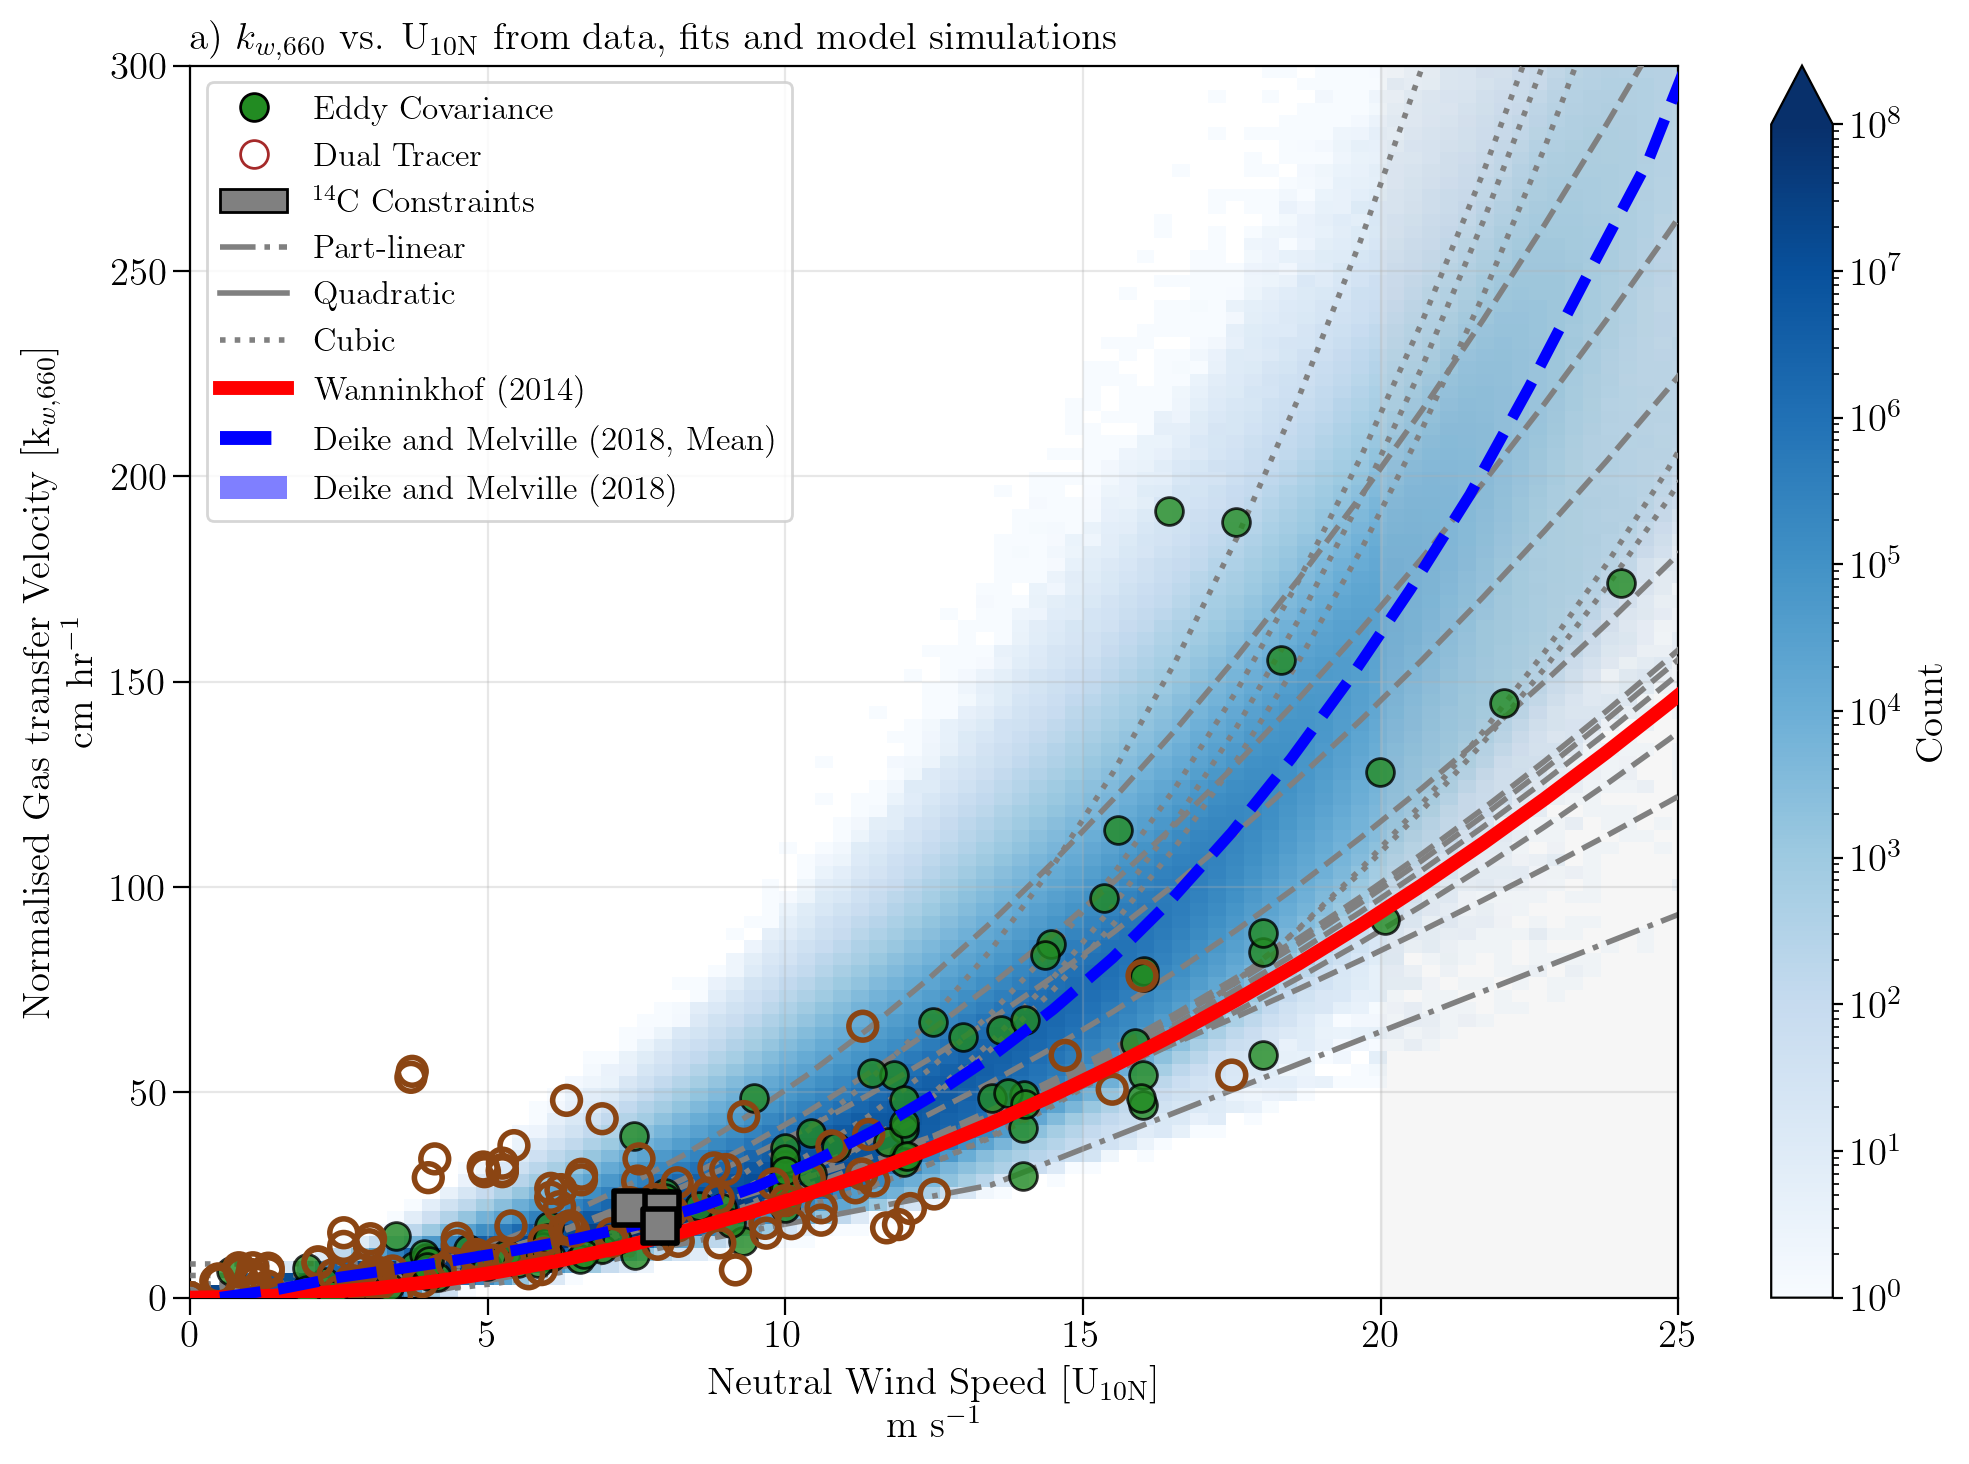

In [7]:
fig, ax = plt.subplots(figsize=(12,8))

##### ============================
##### Step 1: Plot all the EC data
##### ============================

import matplotlib.colors as mcolors

for i in range(len(data_ec_gasex)):
    plt.scatter(data_ec_gasex[i][0], data_ec_gasex[i][1], marker='.', facecolor='forestgreen', edgecolor='black', s = 400, label=label_ec_gasex[i], alpha=0.8, zorder=4)

for i in range(len(y22_data_ec)):
    plt.scatter(y22_data_ec[i][0], y22_data_ec[i][1], marker='.', facecolor='forestgreen', edgecolor='black', s = 400, label=label_ec[i], alpha=0.8, zorder=4)

##### ============================
##### Step 2: Plot all the DT data
##### ============================

DT_u = [DT_Watson_NAtl_u_10[:],DT_Clark_1993_u_10[:],DT_Clark_1994_u_10, DT_Wanninkhof_1997_u_10, DT_Asher_1998_u_10,
     DT_Nightingale_2000_u_10,DT_Wanninkhof_2004_u_10, DT_Ho_2006_u_10, DT_Ho_2011_u_10,
     [0,0], DT_Kubis_open_2019_u_10, DT_Kubis_fjords_2019_u_10]

DT_k = [DT_Watson_NAtl_k_w[:],DT_Clark_1993_k_w[:],DT_Clark_1994_k_w, DT_Wanninkhof_1997_k_w, DT_Asher_1998_k_w,
     DT_Nightingale_2000_k_w,DT_Wanninkhof_2004_k_w, DT_Ho_2006_k_w, DT_Ho_2011_k_w,
     [0,0], DT_Kubis_open_2019_k_w, DT_Kubis_fjords_2019_k_w]

for i in range(len(DT_u)):
    plt.scatter(DT_u[i], DT_k[i], s=100, 
                edgecolor='saddlebrown', facecolor='None',
                marker='o' ,zorder=4, linewidth=2)
    
##### ============================
##### Step 3: Plot all the Radiocarbon constraints
##### ============================

plt.scatter(global_Broecker_c14_u_10,global_Broecker_c14_k_w, marker='s',zorder=7,
            s=150,facecolors='grey', edgecolor='black', linewidth=2,
            label='Global C14 Constraint Broecker (1986)')
plt.scatter(global_c14_u_10,global_c14_k_w, marker='s',zorder=7,
            s=150,facecolors='grey', edgecolor='black',linewidth=2,
            label='Global C14 Constraint Jaehne (1987)')
plt.scatter(global_excess_c14_u_10,global_excess_c14_k_w, marker='s',zorder=7,
            s=150,facecolors='grey',edgecolor='black',linewidth=2,
            label='Global C14 Constraint Naegler (2006)') 

##### ============================
##### Step 4: Plot all fits
##### ============================

cmap = plt.get_cmap('Greys')
colors = [cmap(i/10.0) for i in range(12)]
shades_of_grey = [mcolors.to_hex(color) for color in colors]

for i in range(len(fits_2)):
    plt.plot(np.linspace(0,30,30), fits_2[i], linestyle='dashed', color='grey', label=labels_fits_2[i], linewidth=2, zorder=3)
    
for i in range(len(fits_3)):
    plt.plot(np.linspace(0,30,30), fits_3[i], linestyle='dotted', color='grey', label=labels_fits_3[i], linewidth=2 , zorder=3)

plt.plot(np.linspace(0,30,30), k_lm, color='grey', linewidth=2, linestyle ='dashdot', label='Liss and Merlivat (1986)', zorder=1)
plt.plot(np.linspace(0,30,30), fits_2_W14, color='red',linewidth=5, linestyle ='solid', label='Wanninkhof (2014)', zorder=6)
plt.plot(bin_means['bin'], bin_means['bin_means'], color='blue', linewidth=4, zorder=6, linestyle='dashed', label='Deike and Meville (2018)')


##### ============================
##### Step 5: Plot model points
##### ============================

quad = hist_dm18.plot(cmap='Blues', norm=mpl.colors.LogNorm(vmin=1e0, vmax=1e8), extend='max', zorder=0, cbar_kwargs={'label': 'Count'})
quad.colorbar.ax.tick_params(labelsize=14)  
quad.colorbar.set_label('Count', size=14)  

##### ============================
##### Step 5: Finalise Figure
##### ============================

legend_elements = [Line2D([0], [0], marker='o', color='black', label='Eddy Covariance',
                          markerfacecolor='forestgreen', markersize=10, linewidth=0),
                   Line2D([0], [0], marker='o', color='brown', label='Dual Tracer',
                          markerfacecolor='None', markersize=10, linewidth=0),
                   Patch(facecolor='grey', edgecolor='black',
                         label='$^{14}$C Constraints'), 
                   Line2D([0], [0], color='grey', linestyle='-.', lw=2, label='Part-linear'),
                   Line2D([0], [0], color='grey', linestyle='-', lw=2, label='Quadratic'),
                   Line2D([0], [0], color='grey', linestyle='dotted', lw=2, label='Cubic'),
                   Line2D([0], [0], color='red', lw=5, label='Wanninkhof (2014)'),
                   Line2D([0], [0], color='blue',linestyle='--', lw=5, label='Deike and Melville (2018, Mean)'),
                   Patch(facecolor='blue', edgecolor='none', alpha=0.5,
                         label='Deike and Melville (2018)'), ]
plt.legend(handles=legend_elements, loc=2, fontsize=12)    
plt.title('a) $k_{w,660}$ vs. U$_\mathrm{10N}$ from data, fits and model simulations', loc='left', fontsize=14, fontweight='semibold')

plt.xlabel('Neutral Wind Speed [U$_\mathrm{10N}$] \n m s$^{-1}$',  fontsize=14, )#weight='semibold')
plt.ylabel('Normalised Gas transfer Velocity [k$_{w,660}$] \n cm hr$^{-1}$', fontsize=14)#weight='semibold')

plt.ylim(0,300);plt.xlim(0,25);plt.grid(alpha=0.3, zorder=0)
plt.xticks(fontsize=14);plt.yticks(fontsize=14);
ax.tick_params(axis='both', which='major', length=6, pad=2, direction='out')
plt.axvspan(20,35, color='lightgrey', alpha=0.2, zorder=0)

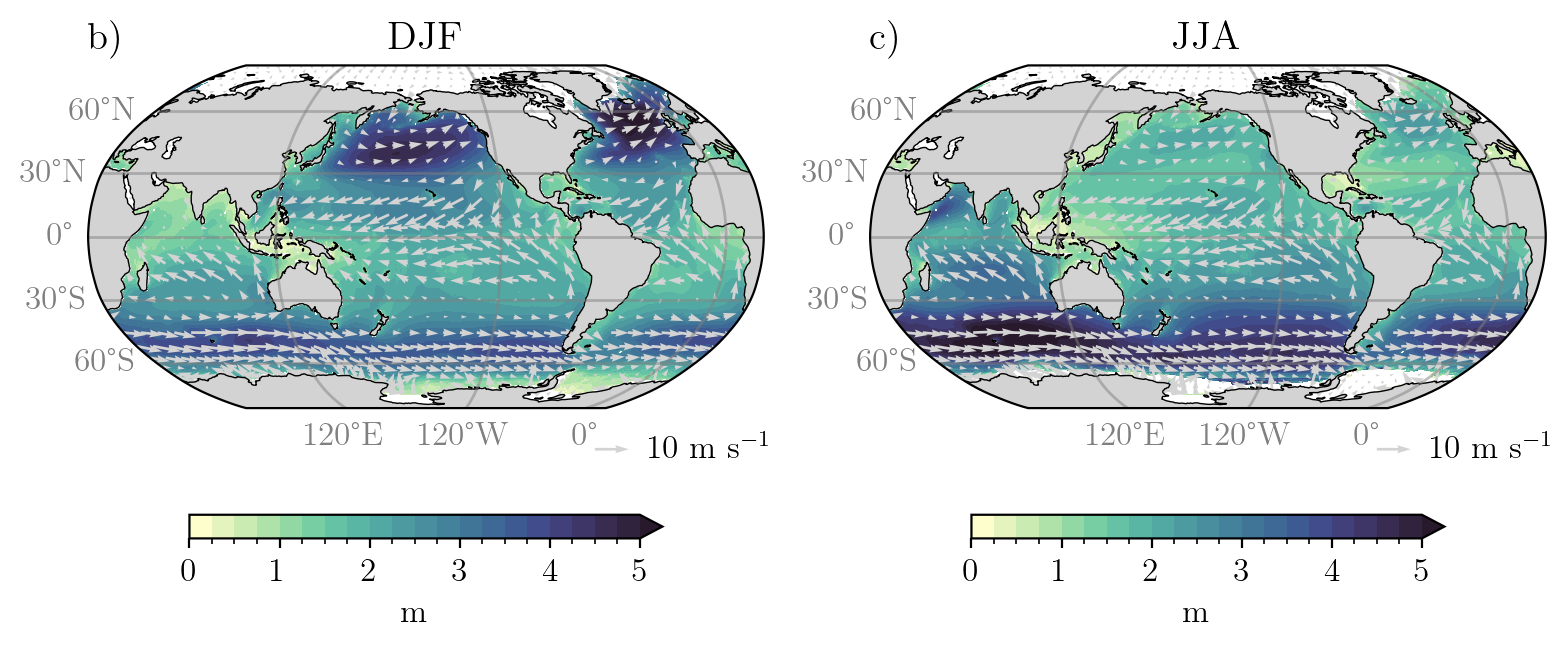

In [47]:
##### ============================
##### Load Data
##### ============================

mean_wave = xr.open_dataset('files/wave_seasonal_means_1971_2020.nc')
mean_wind = xr.open_dataset('files/wind_DJF_JJA_mean_1971_2020.nc')

##### ============================
##### Plot Figure
##### ============================

fig, axes = plt.subplots(1, 2, figsize=(8, 4),
                         subplot_kw={'projection': ccrs.Robinson(200)})

axes = axes.flatten()
titles = ["DJF", "JJA"]
numbers = ["b)", "c)"]
data_list = [
    mean_wave['wave_DJF'].where(glob_ocn_mask),
    mean_wave['wave_JJA'].where(glob_ocn_mask)
]

# Extract wind data
u_wind_fields = [mean_wind['u_wind_DJF'], mean_wind['u_wind_JJA']]
v_wind_fields = [mean_wind['v_wind_DJF'], mean_wind['v_wind_JJA']]

stride = 20
x = mean_wind.xh
y = mean_wind.yh

for i, (ax, wave_data, u_wind, v_wind) in enumerate(zip(axes, data_list, u_wind_fields, v_wind_fields)):
    # Plot wave
    wave_data.plot(
        ax=ax, cmap=cmocean.cm.deep, vmin=0, vmax=5, levels=np.linspace(0, 5, 21), extend='max',
        transform=ccrs.PlateCarree(),
        cbar_kwargs={
            'shrink': 0.7, 'orientation': 'horizontal',
            'label': 'm', 'pad': 0.15, 'ticks': [0, 1, 2, 3, 4, 5]
        })

    # Add quiver (wind vectors)
    q = ax.quiver(
        x[::stride], y[::stride],
        u_wind.values[::stride, ::stride],
        v_wind.values[::stride, ::stride],
        transform=ccrs.PlateCarree(), scale=200, width=0.004, color='lightgrey'
    )
    ax.quiverkey(q, 0.8, -0.12, 10, '10 m s$^{-1}$', labelpos='E')

    # Axes setup
    ax.set_title(titles[i])
    ax.set_title(numbers[i], loc='left', fontsize=14, fontweight='semibold')
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgrey', linewidth=0.5)
    ax.set_global()

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5)
    gl.top_labels = gl.right_labels = False
    gl.left_labels = gl.bottom_labels = True
    gl.xlocator = mticker.FixedLocator([-120, 0, 120])
    gl.xlabel_style = {'size': 12, 'color': 'gray'}
    gl.ylabel_style = {'size': 12, 'color': 'gray'}

plt.tight_layout()

plt.savefig('Figure_01_update.pdf')

# Figure 2

Total impact of wave activity averaged over 1971-2020. a-c) Time-averaged gas transfer velocity ($\overline{k}_{w}$, cm hr$^{-1}$), air-sea CO$_{2}$ partial pressure difference ($\overline{\Delta\text{p}}_\text{CO2}$$, \mu$atm), and air-sea CO$_{2}$ flux ($\overline{\text{F}}_{\text{CO2}}$ positive into the ocean, mol m$^{-2}$ yr$^{-1}$) in the wind-wave-bubble simulation (DM18). d-f) Total influence of wave activity defined as the difference between the wind-wave-bubble and wind-dependent simulations (DM18 - W14) on ${k}_{w}$ ($\Delta{k}_{w}$), $\Delta\text{p}_\text{CO2}$ ($\Delta\Delta\text{p}_{\text{CO2}}$) and $\text{F}_{\text{CO2}}$ ($\Delta\text{F}_{\text{CO2}}$, blue indicates reinforced uptake or suppressed outgassing). g-i) Contributions from $\Delta k_w$ and $\Delta\Delta$pCO$_{\mathrm{2}}$ effects to $\Delta\text{F}_{\text{CO2}}$ that sum up to the reconstructed $\Delta$F$_\text{CO2}$. The $\Delta k_w$ effect includes the cross term in Eq. 8, with further details in the Methods section 2.3.1. Stippling indicates where oceanic carbon uptake occurs in the wind-wave-bubble simulation (i.e., blue in b,c). Regions with winter sea ice cover are masked.

## Panels a-f

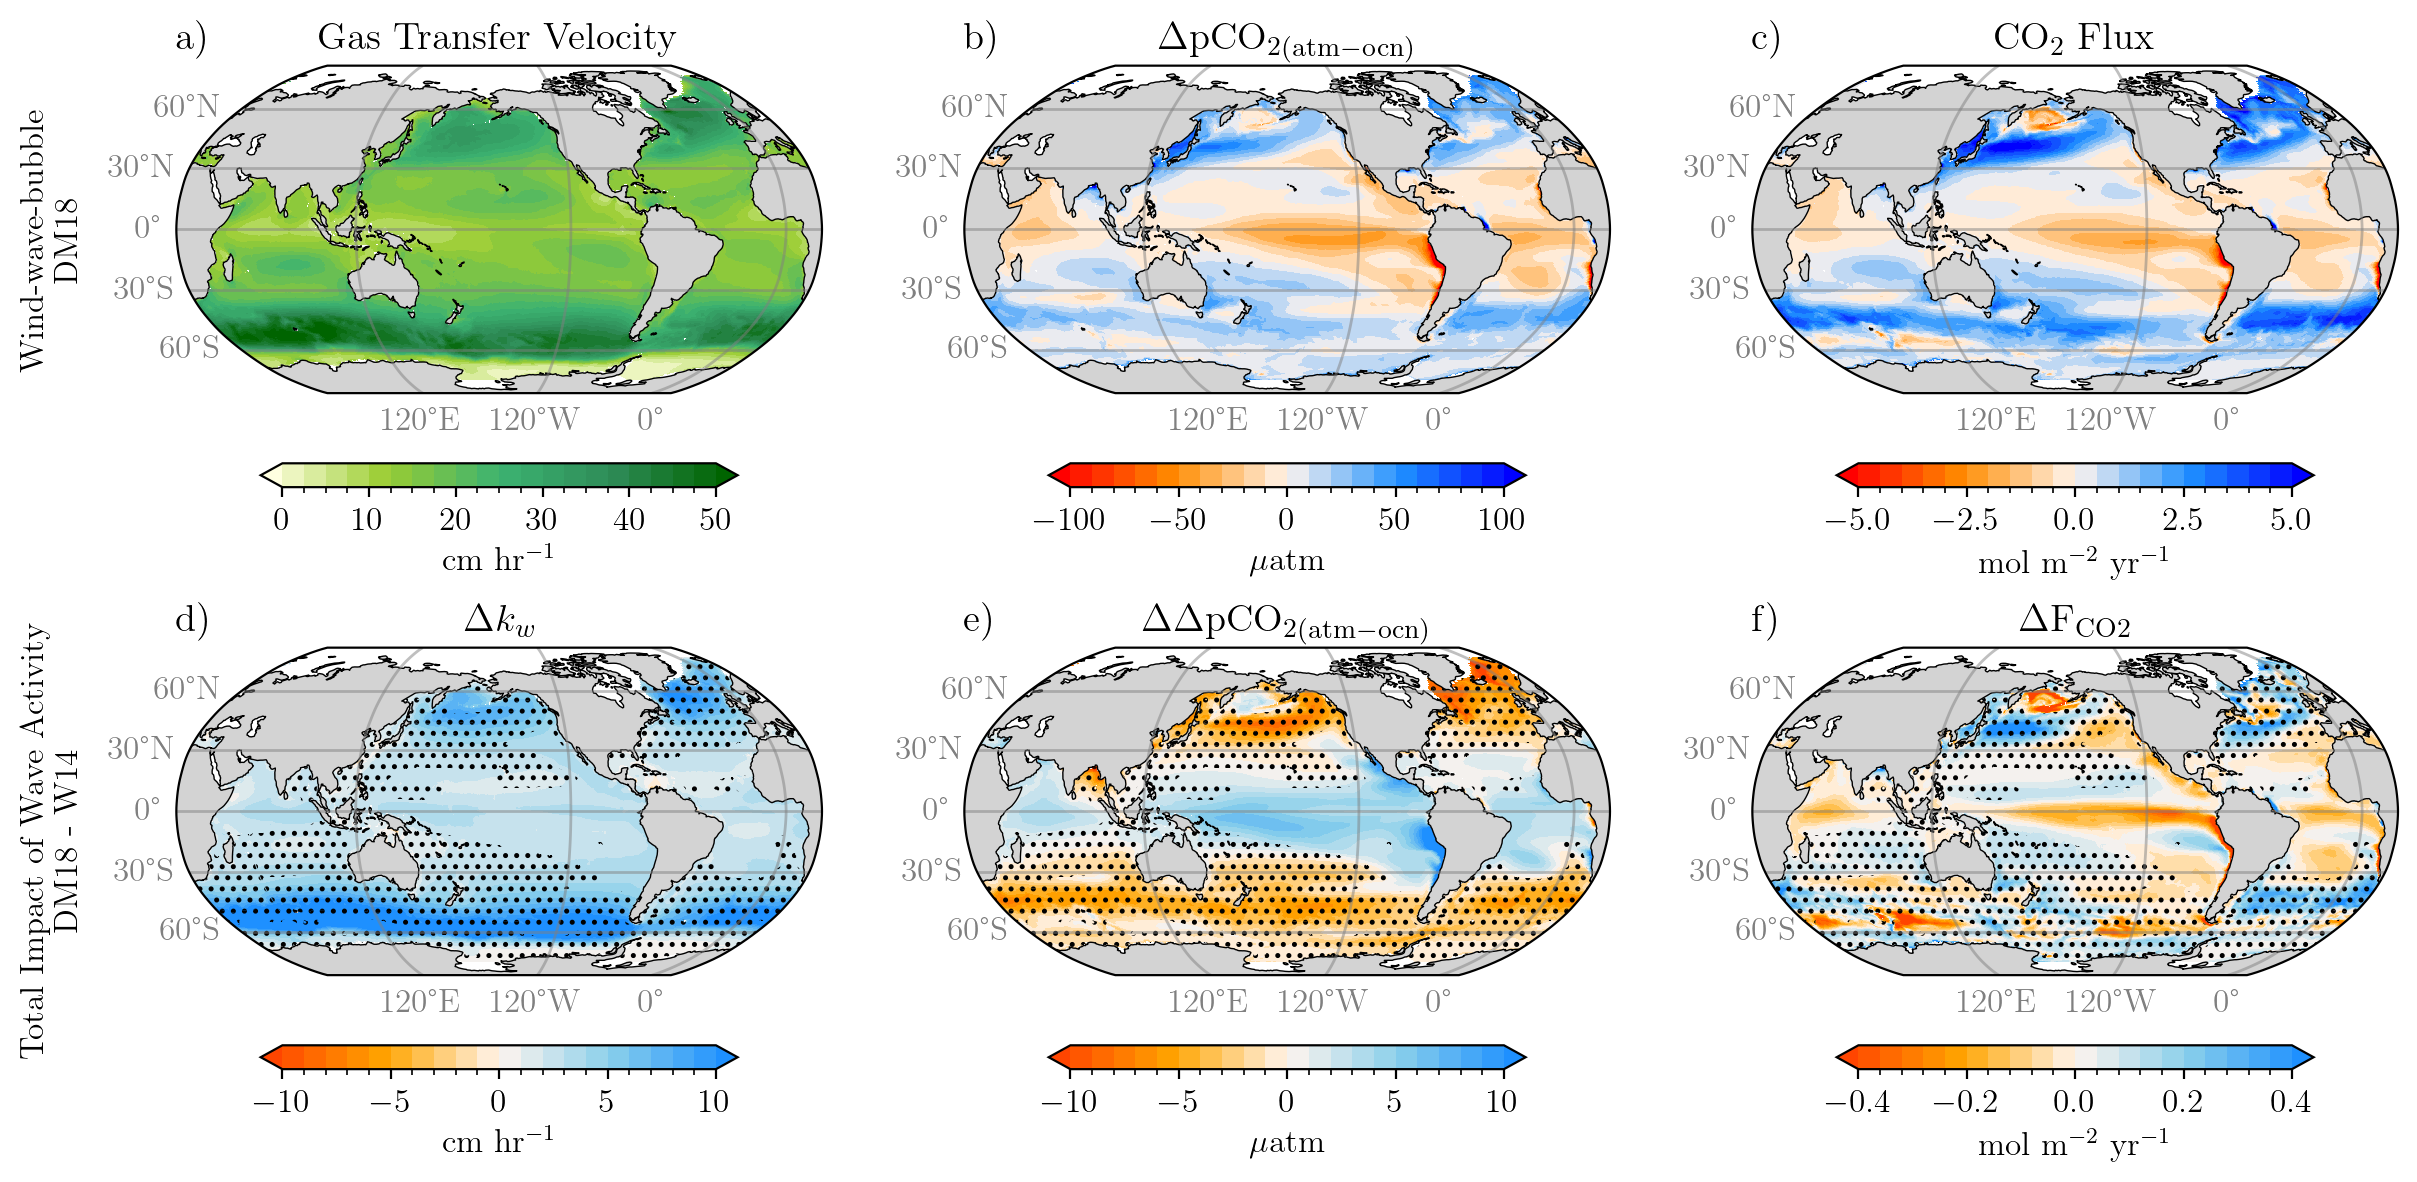

In [10]:
##### ============================
##### Load data
##### ============================

#===== Gas Transfer Velocity =====

dm18_kw_mean = xr.open_dataset('files/dm18_kw_icecorrected_mean_1971_2020.nc')['dic_kw']
w14d_kw_mean = xr.open_dataset('files/w14d_kw_icecorrected_mean_1971_2020.nc')['dic_kw']

#===== Delta pCO2 =====
# path_save = '/projects/GEOCLIM/LRGROUP/prustogi/kw_simulations_2024/Review/'
dm18_dpco2_mean = xr.open_dataset('files/dm18_dpco2_mean_1971_2020.nc')['dic_deltap']
w14d_dpco2_mean = xr.open_dataset('files/w14d_dpco2_mean_1971_2020.nc')['dic_deltap']

#===== CO2 Flux =====
dm18_flux_sum = xr.open_dataset("files/fco2_mean_1971_2020_dm18.nc")['fco2_mean']
w14d_flux_sum = xr.open_dataset("files/fco2_mean_1971_2020_w14d.nc")['fco2_mean']

##### ============================
##### Plot Figure
##### ============================

fig, axs = plt.subplots(2, 3, figsize=(12, 6), subplot_kw={'projection': ccrs.Robinson(200)})
axs = axs.flatten()

cmap_kw = LinearSegmentedColormap.from_list('custom_kw', ['lightyellow', 'yellowgreen', 'mediumseagreen', 'seagreen', 'darkgreen'], N=22)
cmap_flux = LinearSegmentedColormap.from_list('custom_flux', ['red', 'darkorange', 'seashell', 'dodgerblue', 'blue'], N=22)
cmap_dflux = LinearSegmentedColormap.from_list('custom_dflux', ['orangered', 'orange', 'seashell', 'skyblue', 'dodgerblue'], N=22)

mask = dm18_flux_sum.where(dm18_flux_sum >= 0.01)


all_data = [dm18_kw_mean.where(glob_ocn_mask), dm18_dpco2_mean.where(glob_ocn_mask)*-1, dm18_flux_sum.where(glob_ocn_mask),
            w14d_kw_mean.where(glob_ocn_mask), w14d_dpco2_mean.where(glob_ocn_mask)*-1, w14d_flux_sum.where(glob_ocn_mask)]
titles = ["Gas Transfer Velocity", "$\Delta$pCO$_2$$_\mathrm{(atm - ocn)}$", "CO$_2$ Flux",
          "$\Delta k_{w}$", "$\Delta \Delta$pCO$_2$$_\mathrm{(atm - ocn)}$", "$\Delta$F$_\mathrm{CO2}$"]
numbers = ["a)", "b)", "c)", "d)", "e)", "f)"]
cmaps = [cmap_kw, cmap_flux, cmap_flux, cmap_dflux, cmap_dflux, cmap_dflux]
vmins = [0, -100, -50, -10, -10, -0.4]
vmaxs = [50, 100, 50, 10, 10, 0.4]
levels_list = [np.linspace(0, 50, 21), np.linspace(-100, 100, 21), np.linspace(-5, 5, 21),
               np.linspace(-10, 10, 21), np.linspace(-10, 10, 21), np.linspace(-0.4, 0.4, 21)]
ticks_list = [[0, 10, 20, 30, 40, 50], [-100, -50, 0, 50, 100], [-5, -2.5, 0, 2.5, 5],
              [-10, -5, 0, 5, 10], [-10, -5, 0, 5, 10], [-0.4, -0.2, 0, 0.2, 0.4]]
units = ['cm hr$^{-1}$', '$\mu$atm', 'mol m$^{-2}$ yr$^{-1}$'] * 2

for i, ax in enumerate(axs):
    data = all_data[i]
    plot = data.plot(
        ax=ax, cmap=cmaps[i], vmin=vmins[i], vmax=vmaxs[i], levels=levels_list[i], extend='both', transform=ccrs.PlateCarree(),
        cbar_kwargs={'shrink': 0.7, 'orientation': 'horizontal', 'label': units[i], 'pad': 0.15, 'ticks': ticks_list[i]})
 
    if i in [3, 4, 5]:
        ax.contourf(data.xh, data.yh, mask,
            colors='none', hatches=[3*'.'], transform=ccrs.PlateCarree())

    ax.set_title(numbers[i], loc='left', fontsize=14, fontweight='semibold')
    ax.set_title(titles[i], fontsize=14)
    ax.coastlines(linewidth=0.5)
    ax.set_global()
    ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgrey', linewidth=0.5)

    gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5)
    gl.top_labels, gl.right_labels = False, False
    gl.left_labels, gl.bottom_labels = True, True
    gl.xlocator = mticker.FixedLocator([-120, 0, 120])
    gl.xlabel_style = {'size': 12, 'color': 'gray'}
    gl.ylabel_style = {'size': 12, 'color': 'gray'}

fig.text(0, 0.8, "Wind-wave-bubble\nDM18", va='center', ha='center', fontsize=12, rotation='vertical')
fig.text(0, 0.3, "Total Impact of Wave Activity\nDM18 - W14", va='center', ha='center', fontsize=12, rotation='vertical')

plt.tight_layout()

## Panels g-i

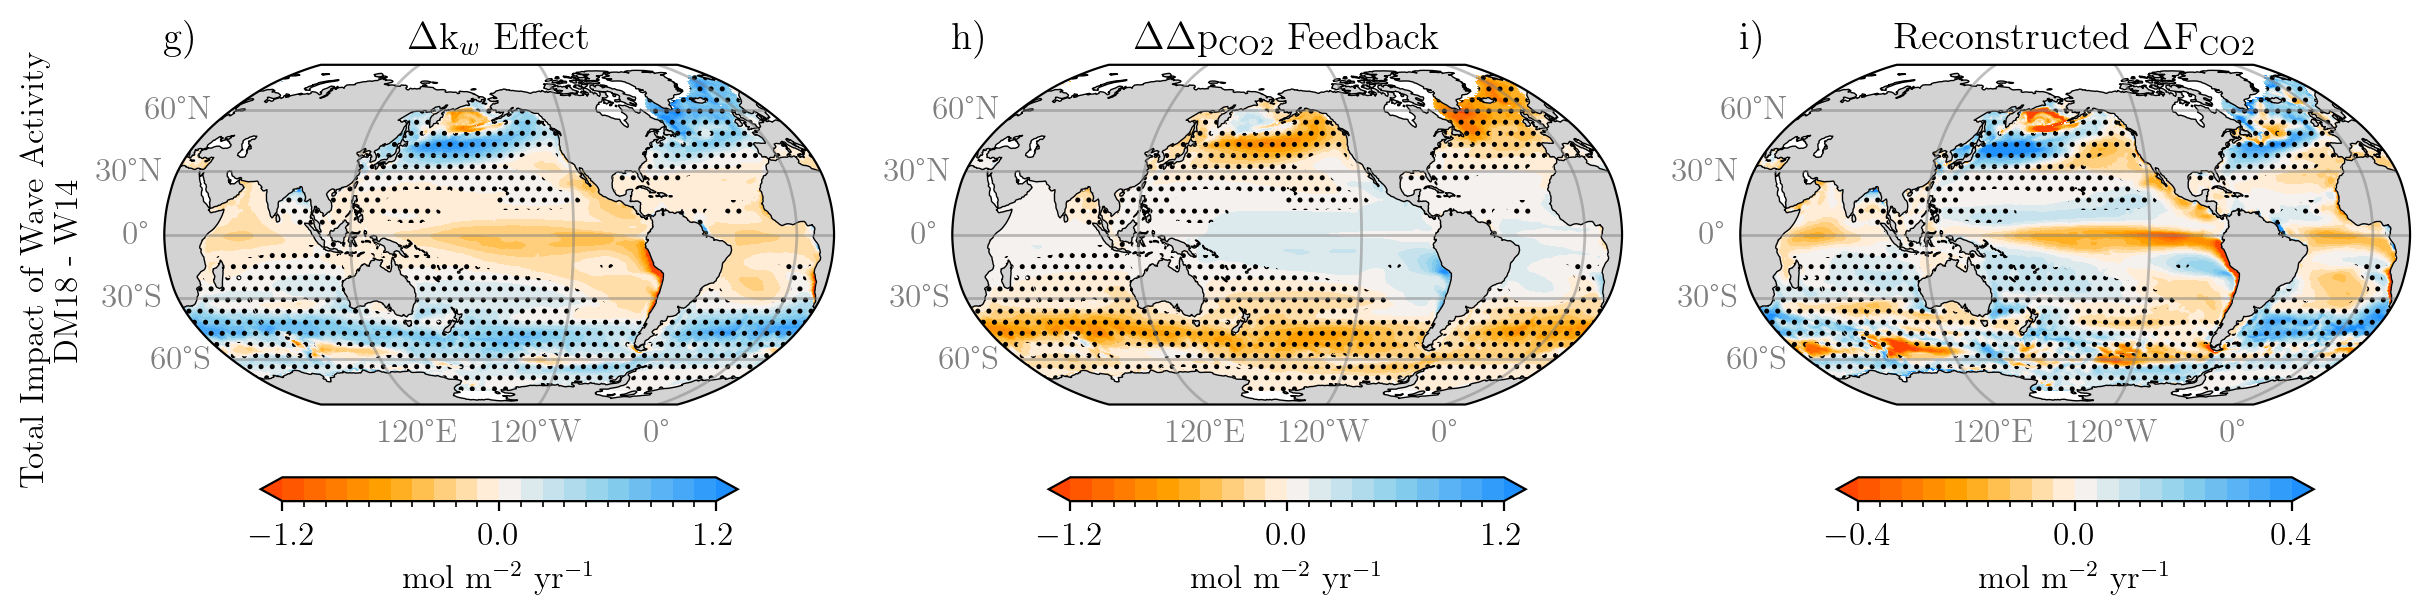

In [22]:
##### ============================
##### Load data
##### ============================

deltaF = xr.open_dataset('files/deltaF_decomposition_50yr_mean.nc')

##### ============================
##### Plot Figure
##### ============================

fig, axes = plt.subplots(1, 3, figsize=(12, 3),
                         subplot_kw={'projection': ccrs.Robinson(200)})
axes = axes.flatten()
last_plot = None

titles = [r"$\Delta$k$_w$ Effect", r'$\Delta\Delta$p$_\mathrm{CO2}$ Feedback', r'Reconstructed $\Delta$F$_\mathrm{CO2}$ ']
numbers = ["g)", "h)", "i)"]
data_list = [(deltaF['term_1']/50 + deltaF['term_3']/50), (deltaF['term_2']/50), (deltaF['deltaF']/50)]
vmins = [-1.2, -1.2, -0.4]
vmaxs = [1.2, 1.2, 0.4]

for i, data in enumerate(data_list):
    ax = axes[i]
    []
    # Plot the data on the Robinson projection
    plot = data.where(glob_ocn_mask).plot(ax=ax, cmap=cmap_dflux, vmin=vmins[i], vmax=vmaxs[i], levels=np.linspace(vmins[i], vmaxs[i], 21), extend='both',
                              transform=ccrs.PlateCarree(), 
                              cbar_kwargs = {'shrink': 0.7, 'orientation': 'horizontal', 'label': 'mol m$^{-2}$ yr$^{-1}$',
                                              'pad': 0.15, 'ticks':[vmins[i],0,vmaxs[i]]}) 
    ax.contourf(data.xh, data.yh, mask, colors='none', hatches=[3*'.'], transform=ccrs.PlateCarree())
    ax.set_title(numbers[i], loc='left', fontsize=14, fontweight='semibold')
    ax.set_title(titles[i], fontsize=14)
    ax.coastlines(linewidth=0.5)
    ax.set_global()
    ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgrey', linewidth=0.5)

    gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5)
    gl.top_labels, gl.right_labels = False, False
    gl.left_labels, gl.bottom_labels = True, True
    gl.xlocator = mticker.FixedLocator([-120, 0, 120])
    gl.xlabel_style = {'size': 12, 'color': 'gray'}
    gl.ylabel_style = {'size': 12, 'color': 'gray'}

fig.text(0, 0.6, "Total Impact of Wave Activity\nDM18 - W14", va='center', ha='center', fontsize=12, rotation='vertical')

plt.tight_layout()  

# Figure 03

a) Map of significant wave height \textcolor{blue}{(m)} in the North Atlantic on 15 February 2015, with vectors indicating \textcolor{blue}{10 m} wind speed. Black vectors correspond to a wind speed of 10 m s$^{-1}$. b) Time series of daily CO$_2$ fluxes at one location (60°W, 40°N) from the wind-wave-bubble simulation (DM18, blue line) with $\Delta$F$_\text{CO2}$ with the wind-dependent simulation (DM18 - W14, green line on the right y-axis in units of mmol m$^2$ day$^{-1}$). c) Scatter plot comparing the daily flux estimates at the same point (DM18 - W14). d) Time series of high-frequency (gray) and seasonally (black) filtered $\Delta$F$_\text{CO2}$ at the same location.

/tmp/ipykernel_1305279/1706649582.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout();


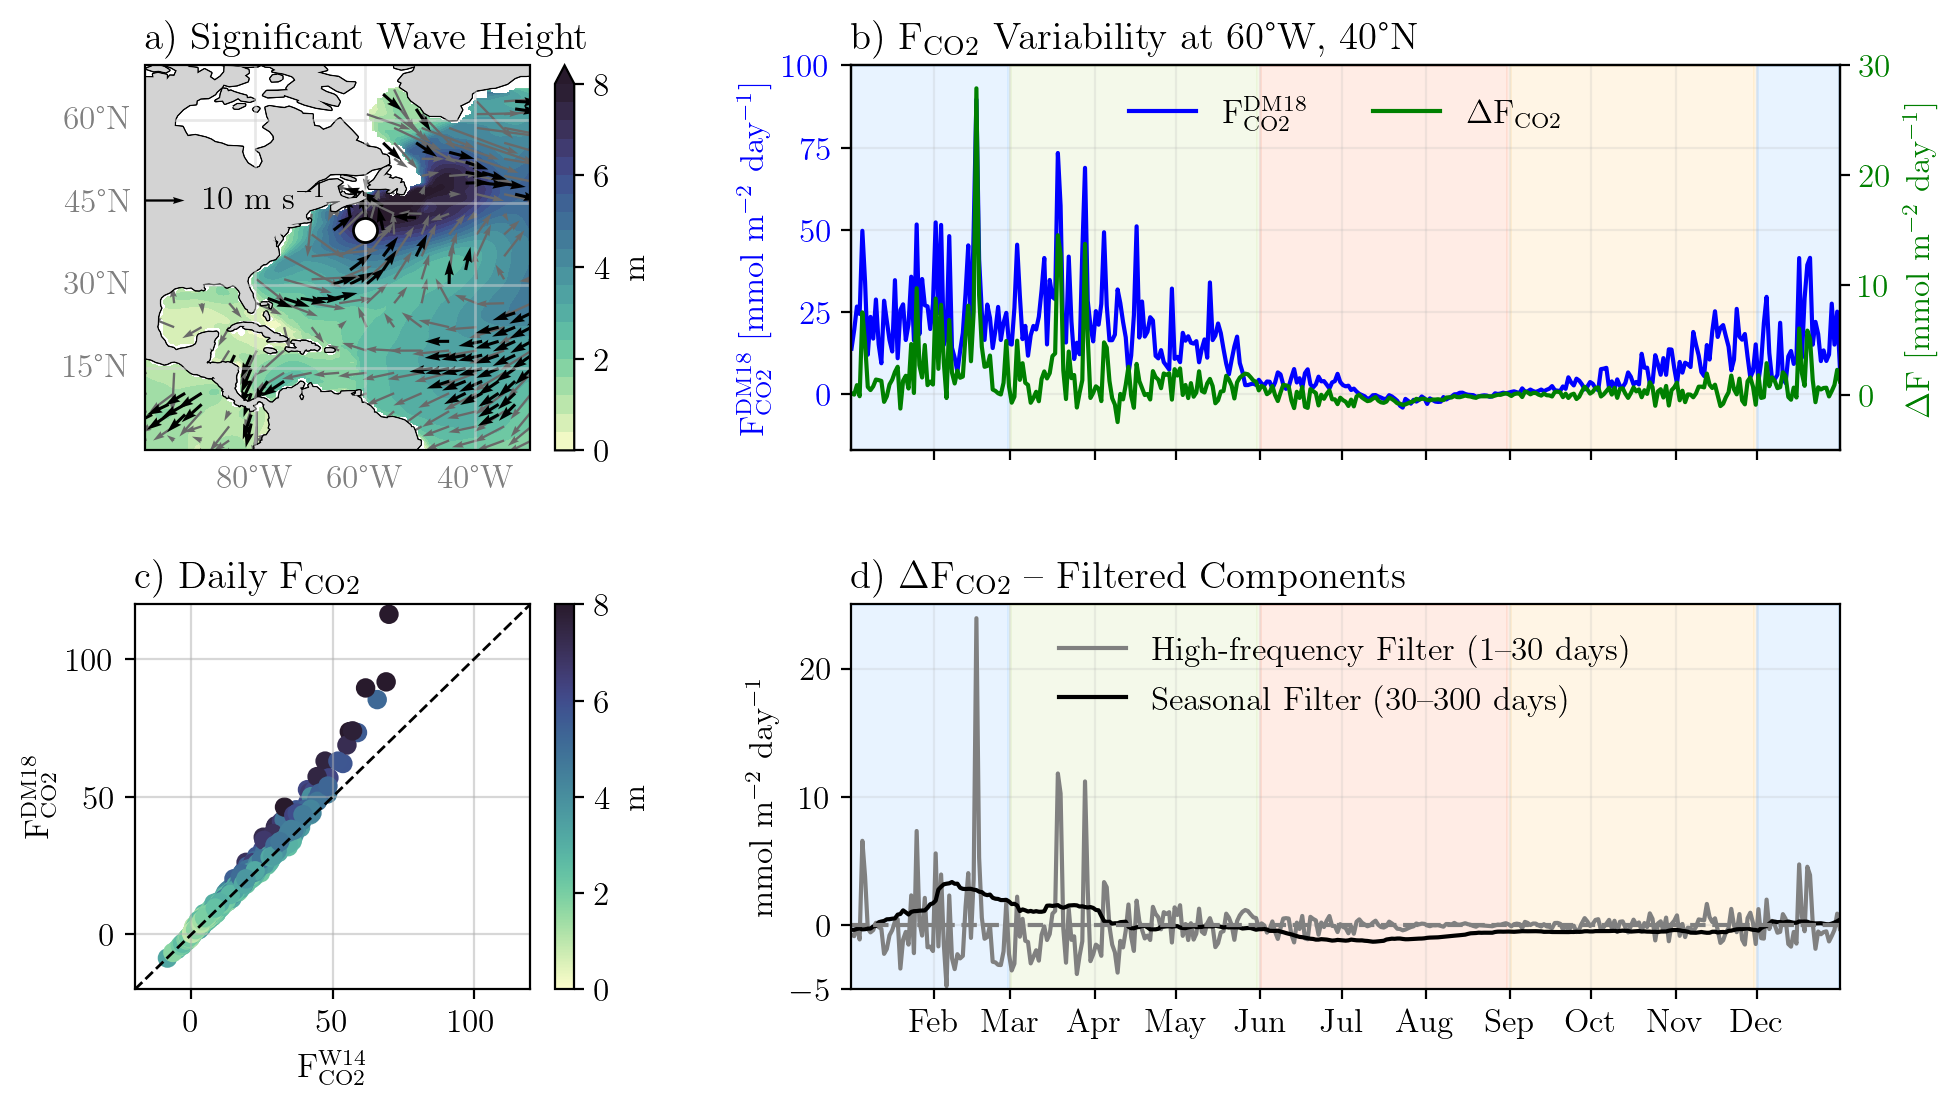

In [46]:
##### ============================
##### Load data
##### ============================

wave_field = xr.open_dataset("files/wave_quiver_day45__60W_40N.nc")
timeseries = xr.open_dataset("files/fco2_timeseries__60W_40N.nc")
points     = xr.open_dataset("files/fco2_wave_points__60W_40N.nc")

##### ============================
##### Plot Figure
##### ============================

fig = plt.figure(figsize=(11, 6))
gs = gridspec.GridSpec(nrows=2, ncols=2, height_ratios=[1, 1], width_ratios=[1, 2], hspace=0.4, wspace=0.3)

# Coordinates
xh_value_1, yh_value_1 = -60, 40

# Prepare wind speed mask
stride_10 = 6
wind_speed = np.sqrt(
    wave_field['u_wind'][::stride_10, ::stride_10]**2 + wave_field['v_wind'][::stride_10, ::stride_10]**2
)
mask = (wind_speed >= 9) & (wind_speed <= 11)
masked_u = np.ma.masked_where(~mask, wave_field['u_wind'][::stride_10, ::stride_10])
masked_v = np.ma.masked_where(~mask, wave_field['v_wind'][::stride_10, ::stride_10])

# Panel a: Map
ax_map = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())

im = ax_map.contourf(
    wave_field['wave'].xh, wave_field['wave'].yh, wave_field['wave'], 
    levels=np.linspace(0, 8, 21), cmap=cmocean.cm.deep, extend='max', transform=ccrs.PlateCarree()
)
ax_map.scatter(xh_value_1, yh_value_1, facecolor='white', edgecolor='black', marker=".", s=300, transform=ccrs.PlateCarree(), zorder=5)
cb = plt.colorbar(im, ax=ax_map, ticks=np.linspace(0, 8, 5), orientation='vertical', extend='neither', pad=0.05)
cb.set_label('m')
ax_map.coastlines()
ax_map.add_feature(cfeature.LAND, zorder=2, facecolor='lightgrey', linewidth=0.5)

ax_map.set_title('a) Significant Wave Height', loc='left', fontsize=14, fontweight='semibold')

# Wind vectors
stride = 10
q = ax_map.quiver(
    wave_field['u_wind'].xh[::stride], wave_field['u_wind'].yh[::stride],
    wave_field['u_wind'][::stride, ::stride], wave_field['v_wind'][::stride, ::stride],
    transform=ccrs.PlateCarree(), scale=100, width=0.006, color='dimgrey')
ax_map.quiver(
    wave_field['u_wind'].xh[::stride_10], wave_field['u_wind'].yh[::stride_10],
    masked_u, masked_v,
    transform=ccrs.PlateCarree(), scale=150, width=0.008, color='black')
ax_map.quiverkey(q, X=0.1, Y=0.65, U=10, label='10 m s$^{-1}$', labelpos='E', color='black', zorder=5)

# Map setup
ax_map.coastlines()
ax_map.add_feature(cfeature.LAND, zorder=2, facecolor='lightgrey', linewidth=0.5)
ax_map.set_extent([-100, -30, 0, 70], crs=ccrs.PlateCarree())

# Gridlines
gl = ax_map.gridlines(draw_labels=True, linewidth=1, color='lightgrey', alpha=0.5)
gl.top_labels, gl.right_labels = False, False
gl.left_labels, gl.bottom_labels = True, True
gl.xlocator = plt.MaxNLocator(4)
gl.ylocator = plt.MaxNLocator(5)
gl.xlabel_style = {'size': 12, 'color': 'gray'}
gl.ylabel_style = {'size': 12, 'color': 'gray'}

ax_map.tick_params(axis='both', which='major', direction='out', length=3, width=1, colors='grey')
ax_map.tick_params(axis='both', which='minor', direction='in', length=0, width=1, colors='grey')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color('grey')

# Panel b: Time series
ax_b = fig.add_subplot(gs[0, 1])
ax_bb = ax_b.twinx()
ax_b.plot(timeseries['time'], timeseries['fco2_dm18'], color='blue', linewidth=1.5, label=r'F$_\mathrm{CO2}^\mathrm{DM18}$')
ax_bb.plot(timeseries['time'], timeseries['fco2d'], color='green', linewidth=1.5, label=r'$\Delta$F$_\mathrm{CO2}$')
ax_b.set_ylim(-17, 100); ax_b.set_ylabel('F$_\mathrm{CO2}^\mathrm{DM18}$ [mmol m$^{-2}$ day$^{-1}$]', color='blue')
ax_bb.set_ylim(-5, 30); ax_bb.set_ylabel('$\Delta$F [mmol m$^{-2}$ day$^{-1}$]', color='green')
ax_b.set_xlim(timeseries['time'][0].values, timeseries['time'][-1].values)
ax_b.tick_params(axis='y', labelcolor='blue'); ax_bb.tick_params(axis='y', labelcolor='green')
ax_b.set_xticklabels([])

ax_b.grid(alpha=0.2); ax_b.set_title('b) F$_\mathrm{CO2}$ Variability at 60°W, 40°N', loc='left', fontsize=14, fontweight='semibold')

# Seasonal shading
shades = [('2015-01-01', '2015-02-28', 'dodgerblue'), ('2015-03-01', '2015-05-31', 'yellowgreen'),
          ('2015-06-01', '2015-08-31', 'orangered'), ('2015-09-01', '2015-11-30', 'orange'),
          ('2015-12-01', '2015-12-31', 'dodgerblue')]

# Legends
h1, l1 = ax_b.get_legend_handles_labels()
h2, l2 = ax_bb.get_legend_handles_labels()
ax_b.legend(h1 + h2, l1 + l2, loc='upper center', ncol=2, frameon=False)

# Panel c: Scatter
ax_c = fig.add_subplot(gs[1, 0])
sc = ax_c.scatter(points['fco2_w14'], points['fco2_dm18'], c=points['wave'], cmap=cmocean.cm.deep, vmin=0, vmax=8)
cb = plt.colorbar(sc, ax=ax_c)
cb.set_label('m')
ax_c.plot([-20, 120], [-20, 120], color='black', linestyle='--', linewidth=1)
ax_c.set_xlim(-20, 120); ax_c.set_ylim(-20, 120)
ax_c.set_xlabel("F$_\mathrm{CO2}^\mathrm{W14}$"); ax_c.set_ylabel("F$_\mathrm{CO2}^\mathrm{DM18}$")
ax_c.grid(alpha=0.5); ax_c.set_title("c) Daily F$_\mathrm{CO2}$", loc='left', fontsize=14, fontweight='semibold')

# Panel d: Filtered components
ax_d = fig.add_subplot(gs[1, 1])
ax_d.plot(timeseries['time'], timeseries['hfreq'], color='grey', linewidth=1.5, label='High-frequency Filter (1–30 days)')
ax_d.plot(timeseries['time'], timeseries['seas'], color='black', linewidth=1.5, label='Seasonal Filter (30–300 days)')
ax_d.set_ylim(-5, 25); ax_d.set_ylabel('mmol m$^{-2}$ day$^{-1}$')
ax_d.set_yticks([-5, 0, 10, 20])
ax_d.grid(alpha=0.2); ax_d.axhline(0, color='grey', linestyle='--')
ax_d.set_title('d) $\Delta$F$_\mathrm{CO2}$ – Filtered Components', loc='left', fontsize=14, fontweight='semibold')
ax_d.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax_d.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax_d.set_xlim(timeseries['time'][0].values, timeseries['time'][-1].values)
ax_d.legend(loc='upper center', ncol=1, frameon=False)

for start, end, color in shades:
    ax_b.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=0.1)
    ax_d.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=color, alpha=0.1)

plt.tight_layout();

# Figure 04

Local influence of wind-wave-bubble effects. a-c) Normalized distributions of local daily differences (DM18 - W14) in the gas transfer velocity ($\Delta k_w$, cm hr$^{-1}$), air-sea CO$_{2}$ partial pressure difference ($\Delta\Delta$pCO$_{\mathrm{2}}$, $\mu$atm) and air-sea CO$_2$ flux ($\Delta$F$_\text{CO2}$, mmol m$^{-2}$ day$^{-1}$). Distributions of differences are shown for all model points (green) and storms defined as daily wind speeds exceeding 15 m s$^{-1}$ (purple). Stormy wind speeds correspond to $\sim$2.5\% of all conditions. d-f) Cumulative probability distributions for the variables above. Dots and values indicate median in panels a-c, and the percent of points exceeding the highlighted thresholds in panels d-f.

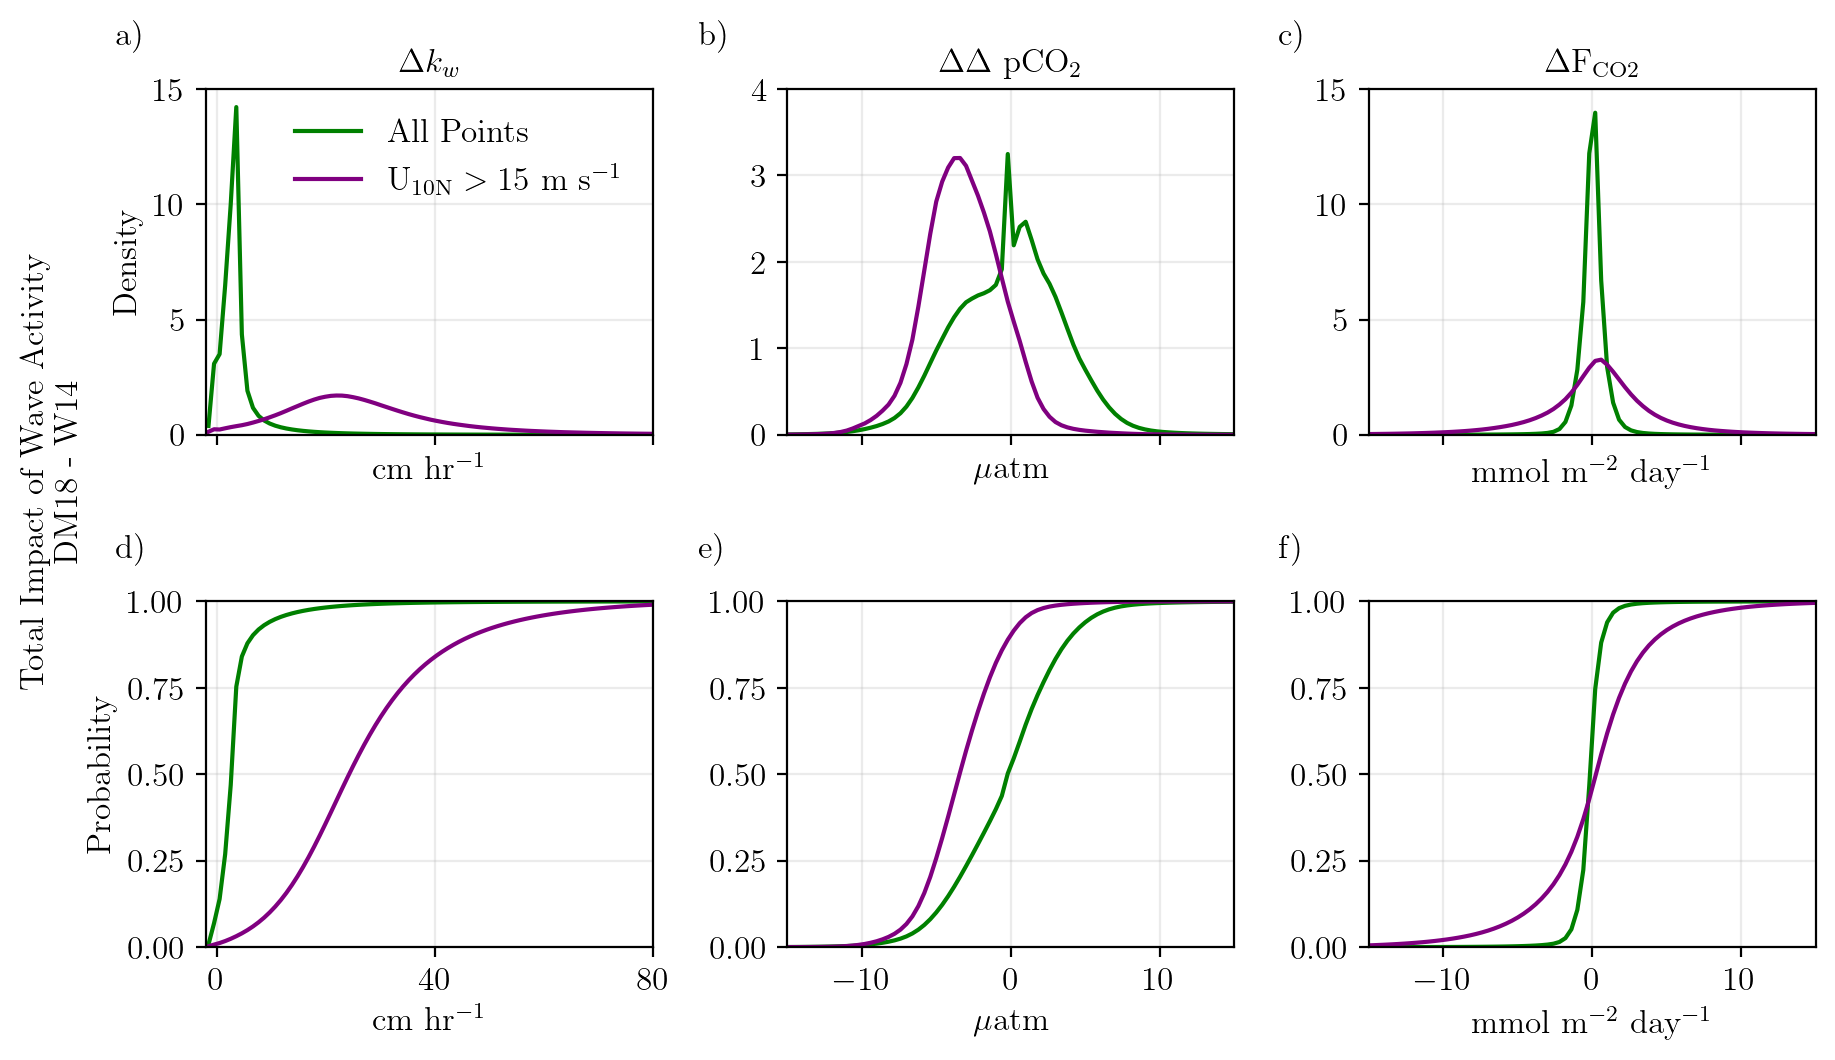

In [34]:
##### ============================
##### Load data
##### ============================

summed_histogram_kw14d_wind  = xr.open_dataset('files/summed_histogram_kw14d_wind.nc')['histogram_dic_kw']
summed_histogram_kw14d_all   = xr.open_dataset('files/summed_histogram_kw14d_all.nc')['histogram_dic_kw'].sum('year')

summed_histogram_f14d_wind   = xr.open_dataset('files/summed_histogram_f14d_wind.nc')['histogram_dic_stf_gas']
summed_histogram_f14d_all    = xr.open_dataset('files/summed_histogram_f14d_all.nc')['histogram_dic_stf_gas'].sum('year')

summed_histogram_dpco2d_wind = xr.open_dataset('files/summed_histogram_dpco2d_wind.nc')['histogram_dic_deltap']
summed_histogram_dpco2d_all  = xr.open_dataset('files/summed_histogram_dpco2d_all.nc')['histogram_dic_deltap']

##### ============================
##### Plot Figure
##### ============================

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(9, 5.5), sharex='col')

# === Define data for density (top row) ===
density_data = [
    (summed_histogram_kw14d_all, summed_histogram_kw14d_wind, r'cm hr$^{-1}$', (-2, 80), [0, 20, 40, 60, 80], (0, 15)),
    (summed_histogram_dpco2d_all, summed_histogram_dpco2d_wind, r'$\mu$atm', (-15, 15), None, (0, 4)),
    (summed_histogram_f14d_all, summed_histogram_f14d_wind, r'mmol m$^{-2}$ day$^{-1}$', (-15, 15), None, (0, 15))]

# === Define data for CDF (bottom row) ===
cdf_data = [
    (summed_histogram_kw14d_all.cumsum()/np.sum(summed_histogram_kw14d_all),
     summed_histogram_kw14d_wind.cumsum()/np.sum(summed_histogram_kw14d_wind),
     r'cm hr$^{-1}$', (-2, 80), [0, 40, 80]),
    
    (summed_histogram_dpco2d_all.cumsum()/np.sum(summed_histogram_dpco2d_all),
     summed_histogram_dpco2d_wind.cumsum()/np.sum(summed_histogram_dpco2d_wind),
     r'$\mu$atm', (-15, 15), None),
    
    (summed_histogram_f14d_all.cumsum()/np.sum(summed_histogram_f14d_all),
     summed_histogram_f14d_wind.cumsum()/np.sum(summed_histogram_f14d_wind),
     r'mmol m$^{-2}$ day$^{-1}$', (-15, 15), None)]

# === Plot each column ===
for i in range(3):
    # --- Top row: Density ---
    all_d, wind_d, xlabel, xlim, xticks, ylim = density_data[i]
    ax = axs[0, i]
    all_d.plot(ax=ax, color='green', label='All Points')
    wind_d.plot(ax=ax, color='purple', label=r'U$_\mathrm{10N}>15$ m s$^{-1}$')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density' if i == 0 else '')
    ax.grid(alpha=0.25)
    if xticks is not None:
        ax.set_xticks(xticks)

    # --- Bottom row: CDF ---
    all_cdf, wind_cdf, xlabel, xlim, xticks = cdf_data[i]
    ax = axs[1, i]
    all_cdf.plot(ax=ax, color='green')
    wind_cdf.plot(ax=ax, color='purple')
    ax.set_xlim(xlim)
    ax.set_ylim(0, 1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Probability' if i == 0 else '')
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.grid(alpha=0.25)
    if xticks is not None:
        ax.set_xticks(xticks)

axs[0, 0].legend( loc=1, frameon=False)

panel_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']

for ax, label in zip(axs.flatten(), panel_labels):
    ax.text(-0.2, 1.2, label, transform=ax.transAxes,
            fontsize=12, fontweight='semibold', va='top', ha='left')

fig.text(0, 0.55, "Total Impact of Wave Activity\nDM18 - W14", va='center', ha='center', fontsize=12, rotation='vertical')
axs[0, 0].set_title(r'$\Delta k_w$', fontsize=12)
axs[0, 1].set_title(r'$\Delta\Delta$ pCO$_{2}$', fontsize=12)
axs[0, 2].set_title(r'$\Delta$F$_\mathrm{CO2}$', fontsize=12)

plt.tight_layout()
plt.show()

# Figure 05

High-frequency (1–30 days) and seasonal (30–300 days) variability ($\pm$2$\sigma$). a,b) Variability in the wind-wave-bubble gas transfer velocity ($k_{w,660}^{\text{DM18}}$). c,d) Difference in gas transfer velocity variability compared with the wind-dependent simulation. e,f) Variability in the air-sea $\Delta$pCO$_{\mathrm{2}}$ ($\mu$atm). g,h) Difference in air-sea $\Delta$pCO$_{\mathrm{2}}$ variability compared with the wind-dependent simulation. i,j) Variability in air-sea CO$_{2}$ flux (mmol m$^{-2}$ day$^{-1}$). k,l) Difference in CO$_{2}$ flux variability compared with the wind-dependent simulation.

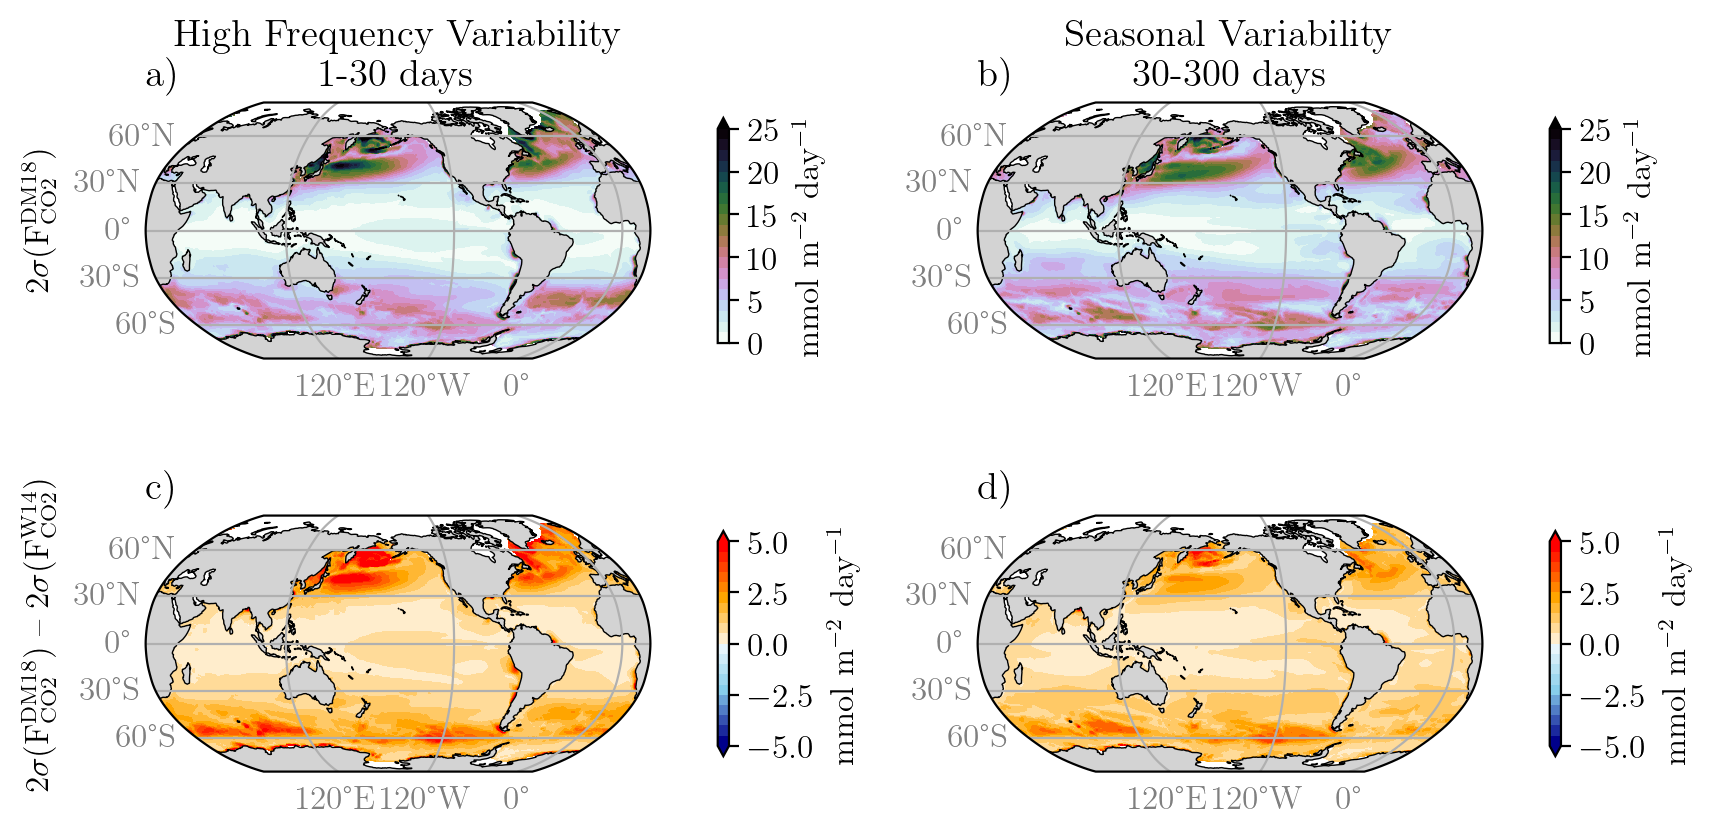

In [39]:
##### ============================
##### Load data
##### ============================

f18_01_30_std   = xr.open_dataset('files/gcb_dm18_flux_01_30_std.nc')['dic_stf_gas'].load()
f18_30_300_std  = xr.open_dataset('files/gcb_dm18_flux_30_300_std.nc')['dic_stf_gas'].load()

f14d_01_30_std  = xr.open_dataset('files/gcb_f14d_01_30_std.nc')['dic_stf_gas'].load()
f14d_30_300_std =xr.open_dataset('files/gcb_f14d_30_300_std.nc')['dic_stf_gas'].load()

##### ============================
##### Plot Figure
##### ============================

fig, axs = plt.subplots(2,2, figsize=(8.5,4.5), sharey=True, subplot_kw={'projection': ccrs.Robinson(central_longitude=200)})

titles = ["High Frequency Variability \n1-30 days", "Seasonal Variability \n30-300 days",
          r'', r'',]
numbers = ["a)", "b)", "c)", "d)"]
data_list = [(2*f18_01_30_std), (2*f18_30_300_std), (2*f14d_01_30_std), (2*f14d_30_300_std)]
level_labels = [6, 6, 5, 5,]

vmins = [0, 0, -5, -5, ]
vmaxs = [25, 25, 5, 5, ]
cmaps = ['cubehelix_r', 'cubehelix_r', cmap_diff, cmap_diff, ]
extends = ['max', 'max', 'both', 'both',]

for ax, title, number, data, vmin, vmax, cmap, extend, level_label in zip(axs.flat, titles, numbers, data_list, vmins, vmaxs, cmaps, extends, level_labels, ):
    colorbar_im = plot_subplot_iav_std(ax, data, title, vmin, vmax, cmap, 21, extend, level_label, 'mmol m$^{-2}$ day$^{-1}$')
fig.text(-0.01, 0.72, r'2$\sigma$(F$_\mathrm{CO2}^\mathrm{DM18}$)', fontsize=12, rotation='vertical', color='black', va='center')
fig.text(-0.01, 0.26, r'2$\sigma$(F$_\mathrm{CO2}^\mathrm{DM18}$) – 2$\sigma$(F$_\mathrm{CO2}^\mathrm{W14}$)', fontsize=12, rotation='vertical', color='black', va='center')

plt.tight_layout();

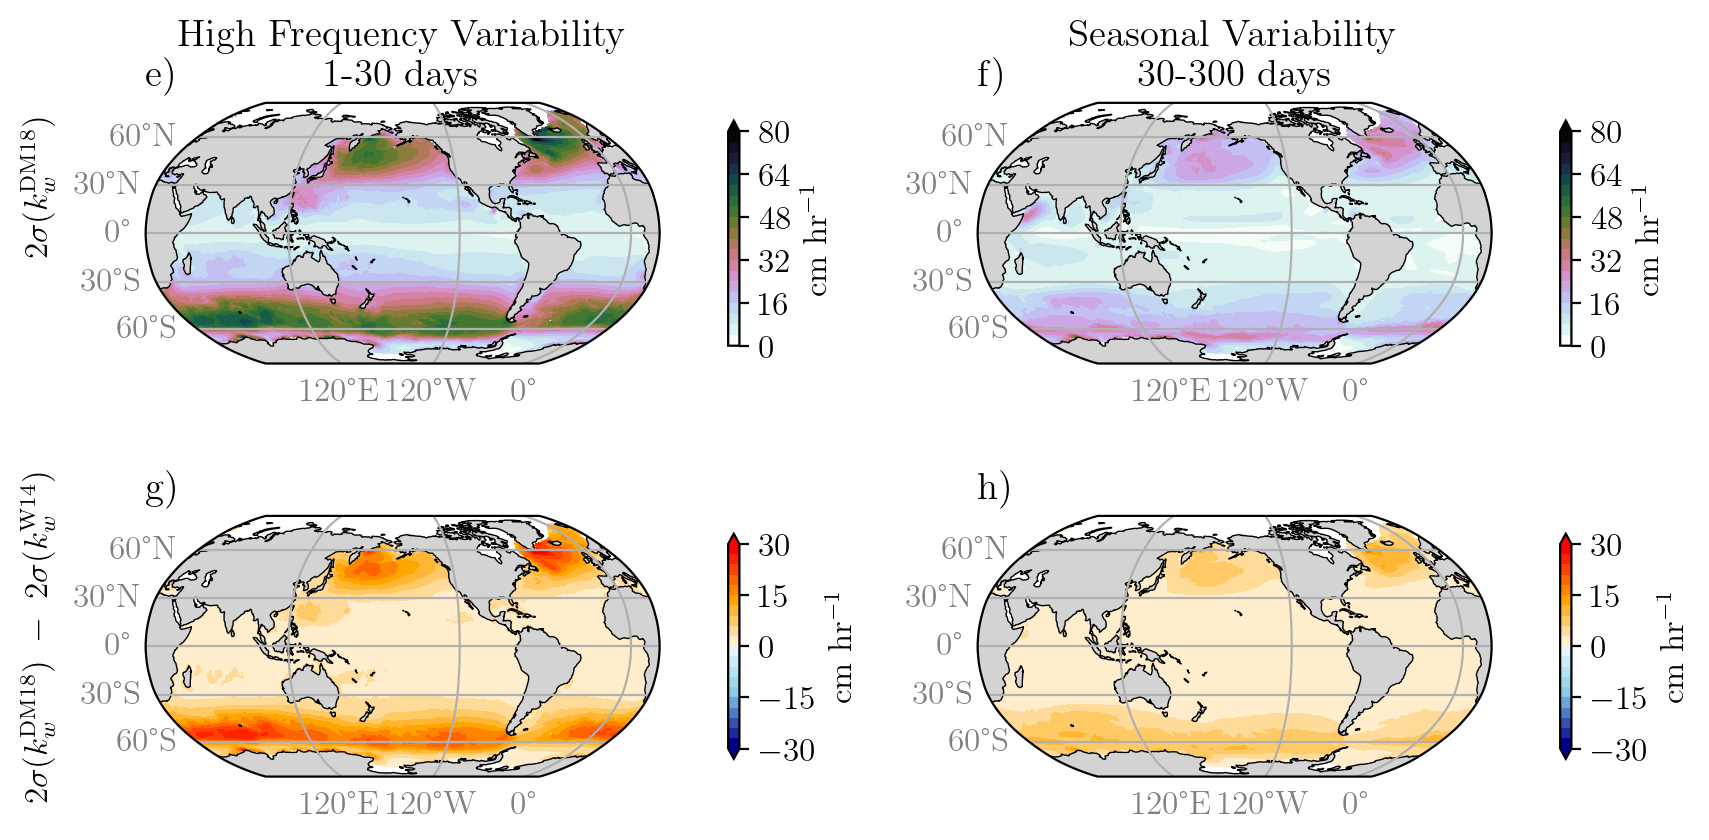

In [41]:
##### ============================
##### Load data
##### ============================

kw18_01_30_std   = xr.open_dataset('files/gcb_dm18_kw_01_30_std.nc')['dic_kw'].load()
kw18_30_300_std  = xr.open_dataset('files/gcb_dm18_kw_30_300_std.nc')['dic_kw'].load()

kw14d_01_30_std  = xr.open_dataset('files/gcb_kw14d_01_30_std.nc')['dic_kw'].load()
kw14d_30_300_std =xr.open_dataset('files/gcb_kw14d_30_300_std.nc')['dic_kw'].load()

##### ============================
##### Plot Figure
##### ============================

fig, axs = plt.subplots(2,2, figsize=(8.5,4.5), sharey=True, subplot_kw={'projection': ccrs.Robinson(central_longitude=200)})
titles = ["High Frequency Variability \n1-30 days", "Seasonal Variability \n30-300 days",r'', r'',]
numbers = [ "e)", "f)", "g)", "h)"]
data_list = [(2*kw18_01_30_std), (2*kw18_30_300_std), (2*kw14d_01_30_std), (2*kw14d_30_300_std),]
level_labels = [6, 6, 5, 5, ]

vmins = [ 0,  0,-30,-30]
vmaxs = [80, 80, 30, 30]
cmaps = ['cubehelix_r', 'cubehelix_r', cmap_diff, cmap_diff]
extends = ['max', 'max', 'both', 'both']

for ax, title, number, data, vmin, vmax, cmap, extend, level_label in zip(axs.flat, titles, numbers, data_list, vmins, vmaxs, cmaps, extends, level_labels, ):
    colorbar_im = plot_subplot_iav_std(ax, data, title, vmin, vmax, cmap, 21, extend, level_label, 'cm hr$^{-1}$')

fig.text(-0.01, 0.76, r'$2\sigma(k_{w}^\mathrm{DM18})$', fontsize=12, rotation='vertical', color='black', va='center')
fig.text(-0.01, 0.26, r'$2\sigma(k_{w}^\mathrm{DM18})\ -\ 2\sigma(k_{w}^\mathrm{W14})$', fontsize=12, rotation='vertical', color='black', va='center')

plt.tight_layout();

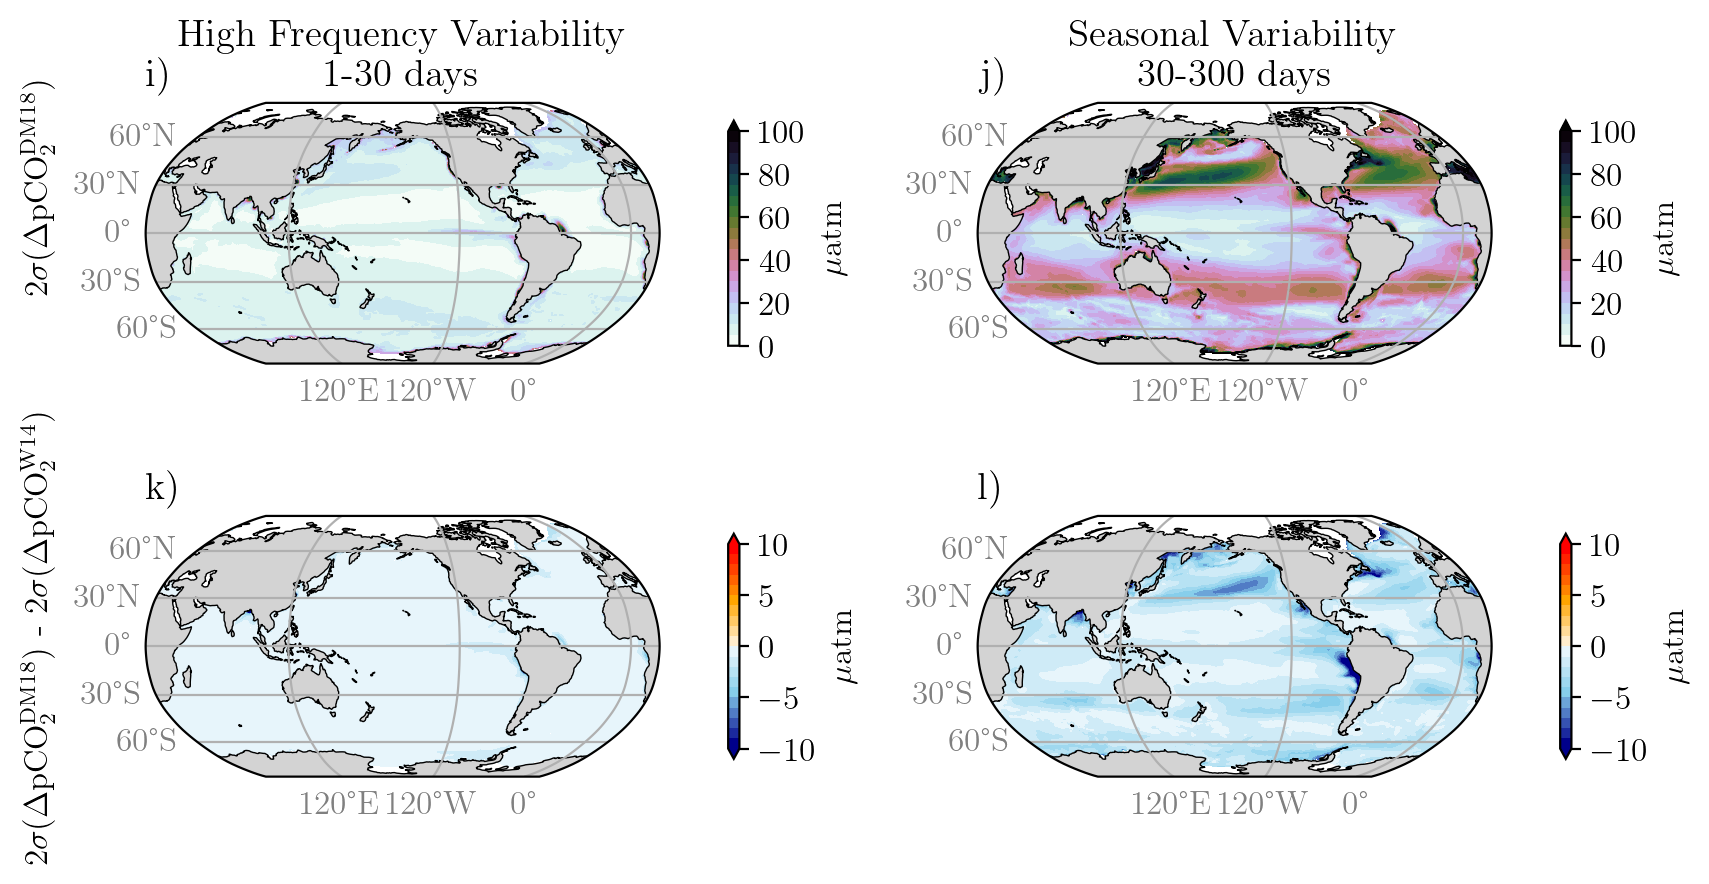

In [42]:
##### ============================
##### Load data
##### ============================

dpco218_01_30_std   = xr.open_dataset('files/gcb_dpco218_01_30_std.nc')['dic_deltap'].load()
dpco218_30_300_std  = xr.open_dataset('files/gcb_dpco218_30_300_std.nc')['dic_deltap'].load()

dpco214d_01_30_std  = xr.open_dataset('files/gcb_dpco214d_01_30_std.nc')['dic_deltap'].load()
dpco214d_30_300_std = xr.open_dataset('files/gcb_dpco214d_30_300_std.nc')['dic_deltap'].load()

##### ============================
##### Plot Figure
##### ============================

fig, axs = plt.subplots(2,2, figsize=(8.5,4.5), sharey=True, subplot_kw={'projection': ccrs.Robinson(central_longitude=200)})

titles = ["High Frequency Variability \n1-30 days", "Seasonal Variability \n30-300 days",r'', r'',]

numbers = ["i)", "j)", "k)", "l)",]
data_list = [(2*dpco218_01_30_std), (2*dpco218_30_300_std), (-2*dpco214d_01_30_std), (-2*dpco214d_30_300_std),]
level_labels = [6, 6, 5, 5]

vmins = [ 0,  0, -10,-10]
vmaxs = [100, 100, 10, 10 ,5, 5, 5, 5]
cmaps = ['cubehelix_r', 'cubehelix_r', cmap_diff, cmap_diff, ]
extends = ['max', 'max', 'both', 'both',]

for ax, title, number, data, vmin, vmax, cmap, extend, level_label in zip(axs.flat, titles, numbers, data_list, vmins, vmaxs, cmaps, extends, level_labels, ):
    colorbar_im = plot_subplot_iav_std(ax, data, title, vmin, vmax, cmap, 21, extend, level_label, '$\mu$atm')
fig.text(-0.01, 0.76, r'2$\sigma$($\Delta$pCO$_{2}^\mathrm{DM18}$)', fontsize=12, rotation='vertical', color='black', va='center')
fig.text(-0.01, 0.26, r'2$\sigma$($\Delta$pCO$_{2}^\mathrm{DM18}$) - 2$\sigma$($\Delta$pCO$_{2}^\mathrm{W14}$)', fontsize=12, rotation='vertical', color='black', va='center')

plt.tight_layout();

# Figure 06

Water masses and carbon storage along a north-south Atlantic section (World Ocean Circulation Experiment Section A16 at 25\textdegree W). a) Decadal trend of DIC concentration ($\mu$mol kg$^{-1}$ decade$^{-1}$) in the wind-wave-bubble (DM18) simulation. b) Mean salinity (psu) along the Atlantic section track in the inset (b). The black contours highlight water masses in the interior, with arrows showing the pathways between the surface and the interior (see Methods section 2.3.4 for details on the water mass framework). c) $\Delta$DIC between simulations (DM18 - W14). d) DIC$^{\prime}$ from wave-induced variability (DM18 - $\langle\text{DM18}\rangle$). The blue and orange colors show DIC gain and loss in the interior. Note the non-uniform y-axis to highlight the upper 1,000~m.

/tmp/ipykernel_6171/3831765596.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


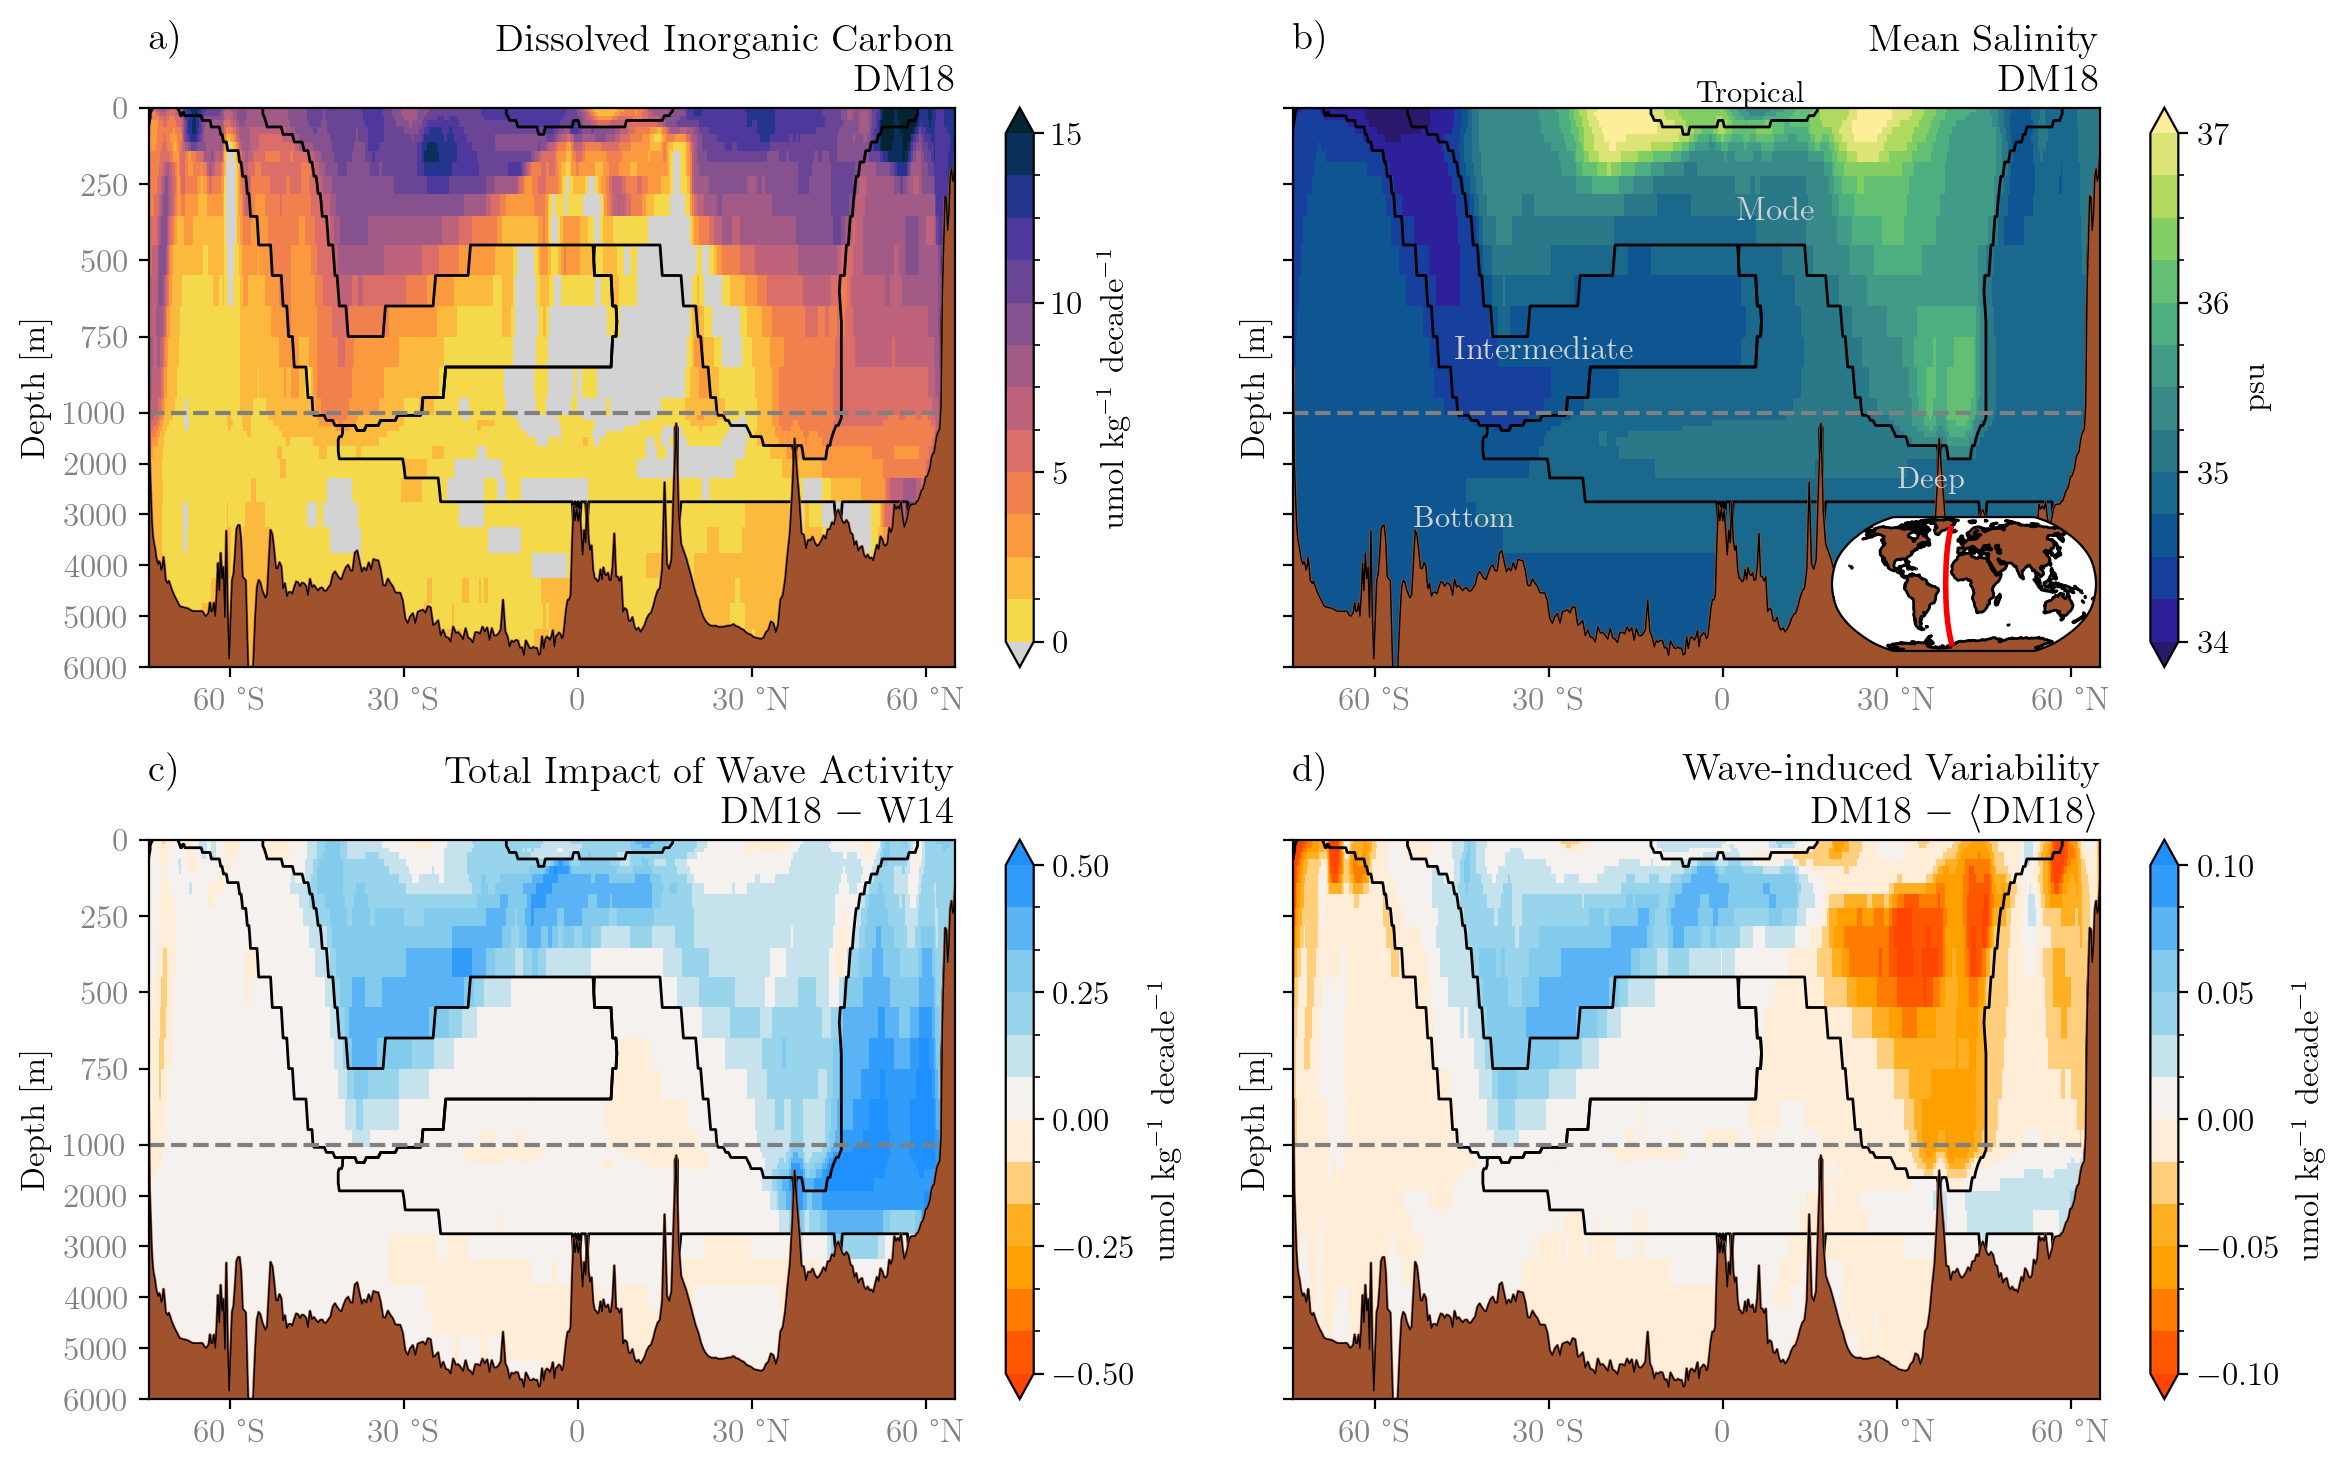

In [63]:
##### ============================
##### Load data
##### ============================

sections = xr.open_dataset("files/atlantic_section_25W.nc")
contours = xr.open_dataset("files/atlantic_watermass_contours_25W.nc")

##### ============================
##### Plot Figure
##### ============================

%matplotlib inline 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from xarrayutils.plotting import linear_piecewise_scale
fig, axs = plt.subplots(2, 2, figsize=(12, 7.5),  sharey=True)

xh_value = -25

data = [sections['dm18_dic_trend'], sections['salinity'], sections['total_wave_impact'], sections['wave_variability']]

section = depth.where(glob_ocn_mask, drop=True).sel(xh=xh_value, method='nearest')       

labels = [
    'Dissolved Inorganic Carbon' + '\n' + 'DM18',
    'Mean Salinity' + '\n' + 'DM18',
    'Total Impact of Wave Activity' + '\n' + 'DM18 $-$ W14',
    r'Wave-induced Variability' + '\n' + r'DM18 $-$ $\langle$DM18$\rangle$']

numbers = ['a) \n', 'b) \n', 'c) \n', 'd) \n']
units = [r'umol kg$^{-1}$ decade$^{-1}$', r'psu',r'umol kg$^{-1}$ decade$^{-1}$', r'umol kg$^{-1}$ decade$^{-1}$']
ticks = [[0,5,10,15], [34, 35, 36, 37], [-0.5, -0.25, 0, 0.25, 0.5], [-0.1, -0.05, 0, 0.05, 0.1]]
vmins = [0, 34, -0.5, -0.1];vmaxs = [15, 37, 0.5, 0.1];levels = [13, 13, 13, 13];cmaps = [cmocean.cm.thermal_r, cmocean.cm.haline, cmap_dflux, cmap_dflux]

for i, ax in enumerate(axs.flatten()):
    im = data[i].plot(yincrease=False, levels=levels[i], vmin=vmins[i], vmax=vmaxs[i], extend='both',
                 cmap = cmaps[i], cbar_kwargs={'label': units[i], 'ticks' : ticks[i]}, ax=ax, )   
 
    ax.invert_yaxis()
    linear_piecewise_scale(1000, 5)
    ax.axhline(1000, color='0.5', ls='--')
    ax.set_yticks([0, 250, 500, 750, 1000, 2000, 3000,4000, 5000, 6000],)
    ax.set_ylim(6000, 0)
    x_values = [-60., -30., 0, 30, 60]
    degree_labels = ['60 °S', '30 °S', '0', '30 °N', '60 °N']
    degree_labels_y = ['0', '250', '500', '750', '1000', '2000', '3000', '4000', '5000', '6000']
    
    ax.set_xticks(x_values, )
    ax.set_xticklabels(degree_labels, color='grey', fontsize=12)
    ax.set_yticklabels(degree_labels_y, color='grey', fontsize=12)
    
    ax.set_xlim(-74, 65)
    
    ax.fill_between(section.yh, 6000, section, color='sienna', zorder=2)
    section.plot(color='black', lw=0.5, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('Depth [m]');
    ax.set_title(numbers[i], loc='left', fontsize=14, fontweight='semibold')
    ax.set_title(labels[i], loc='right', fontsize=14, zorder=5, color='black')

cmaps[0].set_under('lightgrey')
for i, ax in enumerate(axs.flatten()):
    for condition in [contours['stw_mask'], contours['iw_mask'], contours['dw_mask']]:
        condition.plot.contour(ax=ax, levels=[0.5], colors='black', linewidths=1, yincrease=False,
            zorder=1, )        
    ax.set_xlabel('')
    ax.set_ylabel('Depth [m]');

# Create inset axes
inset_ax = plt.axes([0.77, 0.55, 0.11, 0.1], projection=ccrs.Robinson())

plt.plot([-25, -25], [-74, 69], transform=ccrs.PlateCarree(), color='red', linewidth=2) # ATLANTIC
inset_ax.add_feature(cfeature.LAND, zorder=1, facecolor='sienna',linewidth=0.1,)
inset_ax.coastlines()
inset_ax.set_global()
inset_ax.gridlines(draw_labels=False, color='None')

# Add water mass labels to the second plot (axs[0, 1])
ax = axs[0, 1]  # second plot (top-right)

ax.text(0.5, 1.01, 'Tropical', transform=ax.transAxes, fontsize=11, color='black')
ax.text(0.55, 0.8, 'Mode', transform=ax.transAxes, fontsize=12, color='lightgrey')
ax.text(0.20, 0.55, 'Intermediate', transform=ax.transAxes, fontsize=12, color='lightgrey')
ax.text(0.75, 0.32, 'Deep', transform=ax.transAxes, fontsize=11, color='lightgrey')
ax.text(0.15, 0.25, 'Bottom', transform=ax.transAxes, fontsize=11, color='lightgrey')

plt.tight_layout()
plt.show()

# Figure 07

Change in column-integrated DIC storage over 1971-2020. a-c) Column-integrated DIC (mol m$^{-2}$) for the wind-wave-bubble simulation (DM18), and \textcolor{blue}{the \sout{its}} difference due to wave activity (DM18 - W14) and wave-induced variability (DM18 - $\langle\text{DM18}\rangle$). The blue and orange colors show DIC gain and loss, with basin-integrated values in PgC. The contours split the ocean into five basins, excluding the Arctic Ocean. d-f) partitioning of DIC in different water masses, where mode and intermediate waters are combined. Globally integrated values over 1971-2020 in PgC are provided next to the black bars.

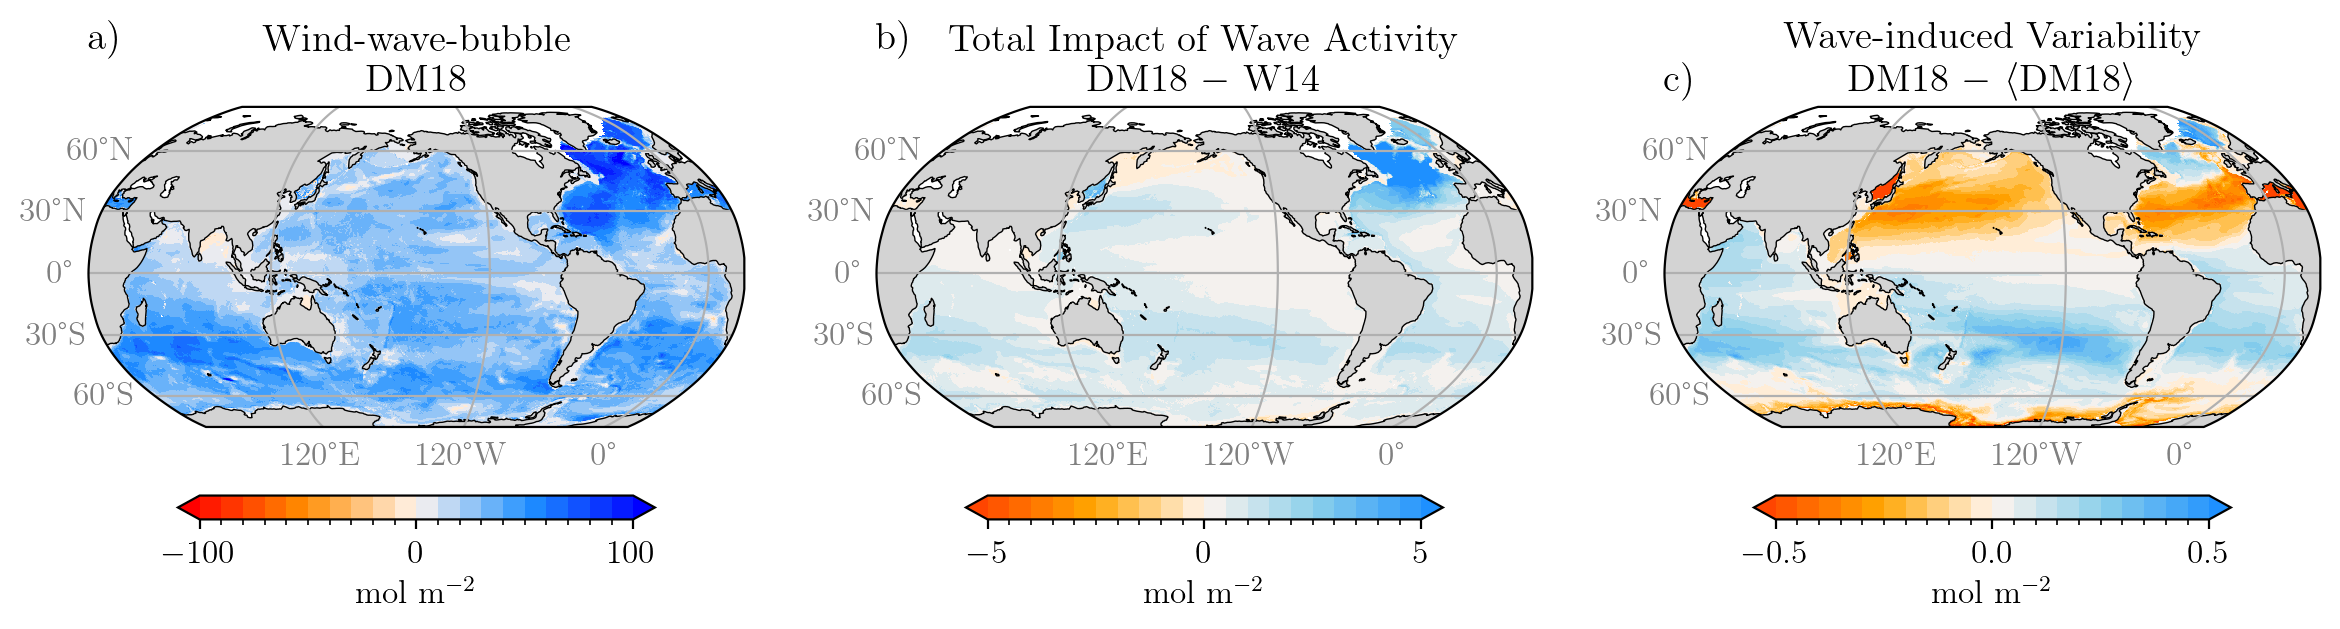

In [43]:
##### ============================
##### Load data
##### ============================

dic_inventory = xr.open_dataset("files/dic_inventory_maps.nc")

##### ============================
##### Plot Figure
##### ============================

fig, axes = plt.subplots(1, 3, figsize=(12, 3), subplot_kw={'projection': ccrs.Robinson(200)})

cmap_flux = LinearSegmentedColormap.from_list('custom_flux', ['red', 'darkorange', 'seashell', 'dodgerblue', 'blue'], N=22)
cmap_dflux = LinearSegmentedColormap.from_list('custom_dflux', ['orangered', 'orange', 'seashell', 'skyblue', 'dodgerblue'], N=22)

axes = axes.flatten()
last_plot = None

titles = [r"Wind-wave-bubble" + "\n" + r"DM18",
          r"Total Impact of Wave Activity" + "\n" + r"DM18 $-$ W14",
          r"Wave-induced Variability" + "\n" + r"DM18 $-$ $\langle$DM18$\rangle$"]
numbers = ["", "", ""]
data_list = [dic_inventory['dm18_dic_map'], dic_inventory['w14d_dic_map'], dic_inventory['dm18d_dic_map']]
vmins = [-100, -5, -0.5]
vmaxs = [100, 5, 0.5]
cmaps = [cmap_flux, cmap_dflux, cmap_dflux]
numbers = ['a) \n', 'b) \n', 'c)']

ticks = [[-100, 0, 100], [-5, 0, 5], [-0.5, 0, 0.5]]

for i, data in enumerate(data_list):
    ax = axes[i]
    
    plot = (data.where(glob_ocn_mask)*50).plot(ax=ax, cmap=cmaps[i], vmin=vmins[i], vmax=vmaxs[i], levels=np.linspace(vmins[i], vmaxs[i], 21), extend='both',
                              transform=ccrs.PlateCarree(), 
                              cbar_kwargs = {'shrink': 0.7, 'orientation': 'horizontal', 'label': 'mol m$^{-2}$',
                                              'pad': 0.15, 'ticks':ticks[i]}) 
    ax.set_title(numbers[i], loc='left', fontsize=14, fontweight='semibold')
    ax.set_title(titles[i], fontsize=14)
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgrey', linewidth=0.5)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    gl.top_labels = False
    gl.xlines = True
    gl.xlocator = mticker.FixedLocator([-120, 0, 120])
    gl.ylocator = mticker.FixedLocator([-60, -30, 0, 30, 60])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12, 'color': 'gray'}
    gl.ylabel_style = {'size': 12, 'color': 'gray'}

plt.tight_layout()  

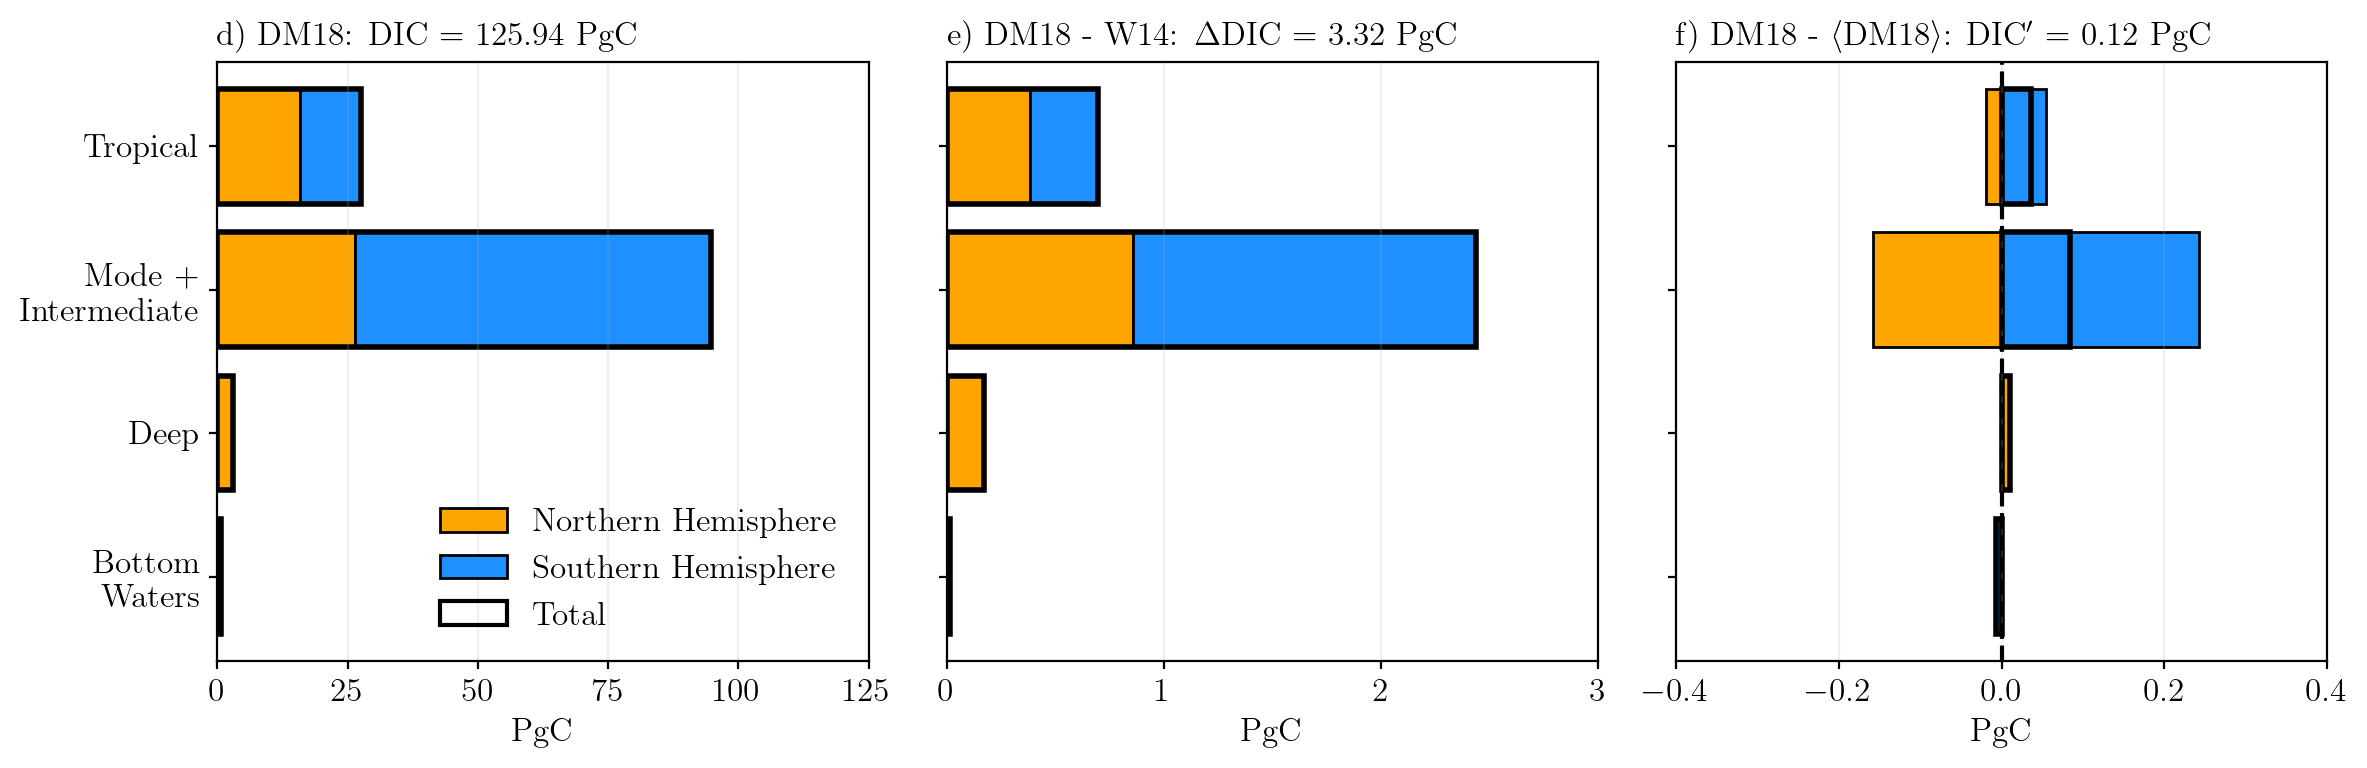

In [44]:
##### ============================
##### Load data
##### ============================

budgets = xr.open_dataset("/projects/GEOCLIM/LRGROUP/prustogi/kw_simulations_2024/Review/Repository/files/dic_inventory_bars.nc")

##### ============================
##### Plot Figure
##### ============================

# Reorder labels and reverse data accordingly
labels = ['Tropical', 'Mode + \n Intermediate', 'Deep', 'Bottom \nWaters']
positions = np.arange(len(labels))

# Flip direction of water masses to match new label order
nh_dm18     = budgets.dm18_dic_inv_nh[::-1]
sh_dm18     = budgets.dm18_dic_inv_sh[::-1]
glob_dm18   = budgets.dm18_dic_inv_glob[::-1]

nh_dm18w14  = budgets.dm18_minus_w14_nh[::-1]
sh_dm18w14  = budgets.dm18_minus_w14_sh[::-1]
glob_dm18w14= budgets.dm18_minus_w14_glob[::-1]

nh_dm18dm18m = budgets.dm18_minus_dm18m_nh[::-1]
sh_dm18dm18m = budgets.dm18_minus_dm18m_sh[::-1]
glob_dm18dm18m = budgets.dm18_minus_dm18m_glob[::-1]

# === Plot ===
fig, (ax, ax1, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# --- Panel a: DM18 ---
bars_nh = ax.barh(positions, nh_dm18, height=0.8, color='orange', edgecolor='black')
bars_sh = ax.barh(positions, sh_dm18, height=0.8, color='dodgerblue', edgecolor='black', left=nh_dm18)
bars_total = ax.barh(positions, glob_dm18, height=0.8, facecolor='None', edgecolor='black', linewidth=2)

ax.set_yticks(positions)
ax.set_yticklabels(labels, size=12)
ax.set_xlabel('PgC', size=12)
ax.set_title(r'd) DM18: DIC = ' + f"{glob_dm18.sum().item():.2f} PgC", loc='left', fontsize=12)
ax.set_xlim(0, 125)
ax.set_xticks([0, 25, 50, 75, 100, 125])
ax.grid(alpha=0.2, zorder=0, axis='x')

# --- Panel b: DM18 - W14 ---
bars_nh = ax1.barh(positions, nh_dm18w14, height=0.8, color='orange', edgecolor='black')
bars_sh = ax1.barh(positions, sh_dm18w14, height=0.8, color='dodgerblue', edgecolor='black', left=nh_dm18w14)
bars_total = ax1.barh(positions, glob_dm18w14, height=0.8, facecolor='None', edgecolor='black', linewidth=2)

ax1.set_xlabel('PgC', size=12)
ax1.set_title(r'e) DM18 - W14: $\Delta$DIC = ' + f"{glob_dm18w14.sum().item():.2f} PgC", loc='left', fontsize=12)
ax1.set_xlim(0, 3)
ax1.set_xticks([0, 1, 2, 3])
ax1.set_yticks(positions)
ax1.set_yticklabels(labels, size=12)
ax1.grid(alpha=0.2, zorder=0, axis='x')

# --- Panel c: DM18 - <DM18> ---
bars_nh = ax3.barh(positions, nh_dm18dm18m, height=0.8, color='orange', edgecolor='black')
bars_sh = ax3.barh(positions, sh_dm18dm18m, height=0.8, color='dodgerblue', edgecolor='black')
bars_total = ax3.barh(positions, glob_dm18dm18m, height=0.8, facecolor='None', edgecolor='black', linewidth=2)

ax3.set_xlabel('PgC', size=12)
ax3.set_title(r'f) DM18 - $\langle$DM18$\rangle$: DIC$^\prime$ = ' + f"{glob_dm18dm18m.sum().item():.2f} PgC", loc='left', fontsize=12)
ax3.set_xlim(-0.4, 0.4)
ax3.set_xticks([-0.4, -0.2, 0, 0.2, 0.4])
ax3.axvline(0, ls='--', color='k')
ax3.set_yticks(positions)
ax3.set_yticklabels(labels, size=12)
ax3.grid(alpha=0.2, zorder=0, axis='x')

# Legend
legend_elements = [
    Patch(facecolor='orange', edgecolor='black', label='Northern Hemisphere'),
    Patch(facecolor='dodgerblue', edgecolor='black', label='Southern Hemisphere'),
    Patch(facecolor='None', edgecolor='black', linewidth=1.5, label='Total')
]
ax.legend(handles=legend_elements, frameon = False, loc='lower right', fontsize=12)

for axis in [ax, ax1, ax3]:
    axis.tick_params(axis='x', labelsize=12)
    axis.tick_params(axis='both', which='minor', length=0)
    axis.tick_params(axis='both', which='major', length=3, pad=3, direction='out')
    axis.invert_yaxis()  # reverse the y-axis

plt.tight_layout()